# ADS Homework 3

## Part 1: Multilayer Perceptron (MLP) — Foundations of Deep Learning

We will use the Wine Quality Dataset for this task, which is proper for both classification and regression task.

### Loading The Dataset

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/wine-quality-dataset")

print("Path to dataset files:", path)

100%|██████████| 21.5k/21.5k [00:00<00:00, 29.8MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/yasserh/wine-quality-dataset/versions/1


In [ ]:
import pandas as pd
import os

# The dataset was downloaded to 'path'
# Let's assume the CSV file is directly in this directory or a subdirectory.
# We will look for a common file name like 'winequality-red.csv' or 'wine.csv'

# List contents of the downloaded directory to find the CSV file
print(f"Contents of {path}:\n{os.listdir(path)}")

# Construct the full path to the CSV file
# Based on common Kaggle dataset structures, it's likely directly under 'path'
# or in a subfolder with a similar name to the dataset (e.g., 'winequality-red.csv')
csv_file_name = "WineQT.csv" # Corrected name for this dataset
full_csv_path = os.path.join(path, csv_file_name)

# Check if the file exists before attempting to read
if os.path.exists(full_csv_path):
    wine_df = pd.read_csv(full_csv_path)

    # Display the first 5 rows
    print("\nFirst 5 rows of the Wine Quality dataset:")
    print(wine_df.head())

    # Display dataset info
    print("\nDataset Info:")
    wine_df.info()
else:
    print(f"Error: CSV file '{csv_file_name}' not found at '{full_csv_path}'. Please check the dataset structure.")

Contents of /root/.cache/kagglehub/datasets/yasserh/wine-quality-dataset/versions/1:
['WineQT.csv']

First 5 rows of the Wine Quality dataset:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 

### Classification Task

We classify each quality above 5 as accepted (1) and others as rejected (0)

#### Dataset Preparation

In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and labels (y)
# 'quality' is the target variable for both classification and regression.
# 'Id' is just an identifier and should be dropped from features.
X = wine_df.drop(['quality', 'Id'], axis=1)
y = wine_df['quality']

# Convert to binary classification labels
y_binary = (y > 5).astype(int)
print(f"Binary Labels (y_binary) shape: {y_binary.shape}")
print("Binary Label Distribution:\n", y_binary.value_counts(normalize=True))

# First split: Training set and a temporary set (validation + test) using binary labels
X_train, X_temp, y_train, y_temp = train_test_split(X, y_binary, test_size=0.3, random_state=42, stratify=y_binary)

# Second split: Validation set and Test set from the temporary set
# We want 15% for validation and 15% for test, so from the 30% temp set, we take half for validation
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Display the shapes of the new datasets
print("\nDataset Split Shapes (Binary Labels):")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"y_val shape:   {y_val.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_test shape:  {y_test.shape}")

# Display value counts for binary quality in each set to verify stratification
print("\nBinary Quality distribution in original dataset:\n", y_binary.value_counts(normalize=True).sort_index())
print("Binary Quality distribution in training set:\n", y_train.value_counts(normalize=True).sort_index())
print("Binary Quality distribution in validation set:\n", y_val.value_counts(normalize=True).sort_index())
print("Binary Quality distribution in test set:\n", y_test.value_counts(normalize=True).sort_index())


Binary Labels (y_binary) shape: (1143,)
Binary Label Distribution:
 quality
1    0.543307
0    0.456693
Name: proportion, dtype: float64

Dataset Split Shapes (Binary Labels):
X_train shape: (800, 11)
y_train shape: (800,)
X_val shape:   (171, 11)
y_val shape:   (171,)
X_test shape:  (172, 11)
y_test shape:  (172,)

Binary Quality distribution in original dataset:
 quality
0    0.456693
1    0.543307
Name: proportion, dtype: float64
Binary Quality distribution in training set:
 quality
0    0.45625
1    0.54375
Name: proportion, dtype: float64
Binary Quality distribution in validation set:
 quality
0    0.45614
1    0.54386
Name: proportion, dtype: float64
Binary Quality distribution in test set:
 quality
0    0.459302
1    0.540698
Name: proportion, dtype: float64


#### The Model

In [ ]:
import torch
from torch import nn

class BinaryMLP(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, num_classes=1):
        super(BinaryMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_size2, num_classes) # Output layer for binary classification

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu1(out)
        out = self.fc2(out)
        out = self.relu2(out)
        out = self.fc3(out)
        return out


#### Training and Optimizarion

Let's try different optimizers and see their difference:

In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from torch import nn
import numpy as np

# Data Preparation
# Convert pandas DataFrames/Series to numpy arrays first, then to PyTorch tensors
X_train_np = X_train.values
y_train_np = y_train.values.astype(np.float32).reshape(-1, 1) # Ensure float32 and correct shape for BCEWithLogitsLoss

X_val_np = X_val.values
y_val_np = y_val.values.astype(np.float32).reshape(-1, 1)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_np)
X_val_scaled = scaler.transform(X_val_np)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_np, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_np, dtype=torch.float32)

# Create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

# Hyperparameters (adjusted for learning rate variations)
input_size = X_train_tensor.shape[1] # 11 features
hidden_size1 = 64
hidden_size2 = 32
num_classes = 1 # For binary classification
num_epochs = 50
batch_size = 32

# Learning rate variations for SGD with Momentum
lr_too_small = 1e-5
lr_good = 1e-3 # From previous best performance
lr_too_large = 0.1
momentum_val = 0.9 # Momentum for SGD

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Training function updated to handle learning rate schedulers
def train_model(model, experiment_name, optimizer_instance, num_epochs, train_loader, val_loader, criterion, device, scheduler=None):
    print(f"--- Training with {experiment_name} ---")
    model.to(device)
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(num_epochs):
        model.train() # Set model to training mode
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for i, (inputs, labels) in enumerate(train_loader):
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Backward and optimize
            optimizer_instance.zero_grad()
            loss.backward()
            optimizer_instance.step()

            running_loss += loss.item() * inputs.size(0)

            # Calculate training accuracy
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        avg_train_loss = running_loss / len(train_dataset)
        train_accuracy = 100 * correct_train / total_train
        train_losses.append(avg_train_loss)
        train_accuracies.append(train_accuracy)

        # Validation phase
        model.eval() # Set model to evaluation mode
        running_val_loss = 0.0
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item() * inputs.size(0)

                predicted = (torch.sigmoid(outputs) > 0.5).float()
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        avg_val_loss = running_val_loss / len(val_dataset)
        val_accuracy = 100 * correct_val / total_val
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_accuracy)

        print(f'Epoch [{epoch+1}/{num_epochs}], '
              f'Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.2f}% | '
              f'Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.2f}%')

        if scheduler:
            scheduler.step() # Step the learning rate scheduler

    print(f"--- {experiment_name} Training Complete ---")
    return train_losses, val_losses, train_accuracies, val_accuracies

# Initialize criterion
criterion = nn.BCEWithLogitsLoss() # Combines Sigmoid and BCE for numerical stability

# --- Experiment 1: SGD with Momentum, Too Small Learning Rate ---
model_lr_small = BinaryMLP(input_size, hidden_size1, hidden_size2, num_classes)
optimizer_lr_small = torch.optim.SGD(model_lr_small.parameters(), lr=lr_too_small, momentum=momentum_val)
lr_small_results = train_model(model_lr_small, f"SGD+Momentum (LR={lr_too_small})", optimizer_lr_small, num_epochs, train_loader, val_loader, criterion, device)
print(f"SGD+Momentum (LR={lr_too_small}) Final Val Acc: {lr_small_results[3][-1]:.2f}%")

# --- Experiment 2: SGD with Momentum, Good Learning Rate (Baseline) ---
model_lr_good = BinaryMLP(input_size, hidden_size1, hidden_size2, num_classes)
optimizer_lr_good = torch.optim.SGD(model_lr_good.parameters(), lr=lr_good, momentum=momentum_val)
lr_good_results = train_model(model_lr_good, f"SGD+Momentum (LR={lr_good})", optimizer_lr_good, num_epochs, train_loader, val_loader, criterion, device)
print(f"SGD+Momentum (LR={lr_good}) Final Val Acc: {lr_good_results[3][-1]:.2f}%")

# --- Experiment 3: SGD with Momentum, Too Large Learning Rate ---
model_lr_large = BinaryMLP(input_size, hidden_size1, hidden_size2, num_classes)
optimizer_lr_large = torch.optim.SGD(model_lr_large.parameters(), lr=lr_too_large, momentum=momentum_val)
lr_large_results = train_model(model_lr_large, f"SGD+Momentum (LR={lr_too_large})", optimizer_lr_large, num_epochs, train_loader, val_loader, criterion, device)
print(f"SGD+Momentum (LR={lr_too_large}) Final Val Acc: {lr_large_results[3][-1]:.2f}%")

# --- Experiment 4: SGD with Momentum, Good Learning Rate + StepLR Scheduling ---
model_lr_scheduled = BinaryMLP(input_size, hidden_size1, hidden_size2, num_classes)
optimizer_lr_scheduled = torch.optim.SGD(model_lr_scheduled.parameters(), lr=lr_good, momentum=momentum_val)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer_lr_scheduled, step_size=15, gamma=0.1) # Reduce LR by factor of 10 every 15 epochs
lr_scheduled_results = train_model(model_lr_scheduled, f"SGD+Momentum (LR={lr_good}) with StepLR", optimizer_lr_scheduled, num_epochs, train_loader, val_loader, criterion, device, scheduler)
print(f"SGD+Momentum (LR={lr_good}) with StepLR Final Val Acc: {lr_scheduled_results[3][-1]:.2f}%")


# --- Report the effect of each learning rate and scheduling ---
print("\n--- Learning Rate and Scheduling Comparison ---")
print(f"SGD+Momentum (LR={lr_too_small}) Final Val Acc: {lr_small_results[3][-1]:.2f}%")
print(f"SGD+Momentum (LR={lr_good}) Final Val Acc: {lr_good_results[3][-1]:.2f}%")
print(f"SGD+Momentum (LR={lr_too_large}) Final Val Acc: {lr_large_results[3][-1]:.2f}%")
print(f"SGD+Momentum (LR={lr_good}) with StepLR Final Val Acc: {lr_scheduled_results[3][-1]:.2f}%")

print("\nEffect of Learning Rate Variations (with SGD+Momentum):")
print("- **Too Small LR (e.g., 1e-5)**: Training is very slow, and the model might converge to a suboptimal solution or get stuck in a flat region. Accuracy improves very gradually, if at all.")
print("- **Good LR (e.g., 1e-3)**: Allows for stable and reasonably fast convergence. The model learns effectively without large oscillations.")
print("- **Too Large LR (e.g., 0.1)**: Can cause the loss to diverge or oscillate wildly, making it impossible for the model to converge. The optimization steps are too big, overshooting the minimum.")

print("\nEffect of Learning Rate Scheduling (StepLR with good LR):")
print("- **StepLR Scheduler**: Initially trains with a relatively high learning rate for faster progress, then reduces it at predefined intervals (e.g., every `step_size` epochs). This helps the model to fine-tune its weights more precisely in later stages of training, potentially leading to better convergence and higher accuracy. It can prevent oscillations towards the end of training that might occur with a fixed high learning rate.")


--- Training with SGD+Momentum (LR=1e-05) ---
Epoch [1/50], Train Loss: 0.7056, Train Acc: 53.38% | Val Loss: 0.7078, Val Acc: 55.56%
Epoch [2/50], Train Loss: 0.7056, Train Acc: 53.38% | Val Loss: 0.7077, Val Acc: 55.56%
Epoch [3/50], Train Loss: 0.7055, Train Acc: 53.38% | Val Loss: 0.7077, Val Acc: 55.56%
Epoch [4/50], Train Loss: 0.7055, Train Acc: 53.38% | Val Loss: 0.7076, Val Acc: 55.56%
Epoch [5/50], Train Loss: 0.7054, Train Acc: 53.38% | Val Loss: 0.7076, Val Acc: 55.56%
Epoch [6/50], Train Loss: 0.7054, Train Acc: 53.38% | Val Loss: 0.7075, Val Acc: 55.56%
Epoch [7/50], Train Loss: 0.7053, Train Acc: 53.38% | Val Loss: 0.7075, Val Acc: 55.56%
Epoch [8/50], Train Loss: 0.7053, Train Acc: 53.38% | Val Loss: 0.7074, Val Acc: 55.56%
Epoch [9/50], Train Loss: 0.7052, Train Acc: 53.38% | Val Loss: 0.7074, Val Acc: 55.56%
Epoch [10/50], Train Loss: 0.7052, Train Acc: 53.38% | Val Loss: 0.7073, Val Acc: 55.56%
Epoch [11/50], Train Loss: 0.7051, Train Acc: 53.38% | Val Loss: 0.7073, 

--- Learning Rate and Scheduling Comparison ---

SGD+Momentum (LR=1e-05) Final Val Acc: 46.20%

SGD+Momentum (LR=0.001) Final Val Acc: 79.53%

SGD+Momentum (LR=0.1) Final Val Acc: 74.85%

SGD+Momentum (LR=0.001) with StepLR Final Val Acc: 73.10%

Effect of Learning Rate Variations (with SGD+Momentum):
- **Too Small LR (e.g., 1e-5)**: Training is very slow, and the model might converge to a suboptimal solution or get stuck in a flat region. Accuracy improves very gradually, if at all.
- **Good LR (e.g., 1e-3)**: Allows for stable and reasonably fast convergence. The model learns effectively without large oscillations.
- **Too Large LR (e.g., 0.1)**: Can cause the loss to diverge or oscillate wildly, making it impossible for the model to converge. The optimization steps are too big, overshooting the minimum.

Effect of Learning Rate Scheduling (StepLR with good LR):
- **StepLR Scheduler**: Initially trains with a relatively high learning rate for faster progress, then reduces it at predefined intervals (e.g., every `step_size` epochs). This helps the model to fine-tune its weights more precisely in later stages of training, potentially leading to better convergence and higher accuracy. It can prevent oscillations towards the end of training that might occur with a fixed high learning rate.

In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from torch import nn
import numpy as np
import matplotlib.pyplot as plt

# Data Preparation (already done, just re-referencing tensors)
X_train_np = X_train.values
y_train_np = y_train.values.astype(np.float32).reshape(-1, 1)
X_val_np = X_val.values
y_val_np = y_val.values.astype(np.float32).reshape(-1, 1)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_np)
X_val_scaled = scaler.transform(X_val_np)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_np, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_np, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

# Hyperparameters (fixed optimizer and LR)
input_size = X_train_tensor.shape[1] # 11 features
hidden_size1 = 64
hidden_size2 = 32
num_classes = 1 # For binary classification
fixed_lr = 1e-3
fixed_momentum = 0.9
max_epochs_for_es = 150 # Max epochs to allow early stopping to run
patience = 10 # How many epochs to wait for improvement

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = nn.BCEWithLogitsLoss()

# New Training function with Early Stopping and Batch Size as parameter
def train_model_with_options(
    batch_size, patience, max_epochs,
    experiment_name,
    input_size, hidden_size1, hidden_size2, num_classes,
    fixed_lr, fixed_momentum, criterion, device
):
    print(f"--- {experiment_name} (Batch Size: {batch_size}, Patience: {patience}, Max Epochs: {max_epochs}) ---")

    # Re-initialize model and optimizer for each experiment
    model = BinaryMLP(input_size, hidden_size1, hidden_size2, num_classes)
    optimizer = torch.optim.SGD(model.parameters(), lr=fixed_lr, momentum=fixed_momentum)
    model.to(device)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    best_val_loss = float('inf')
    epochs_no_improve = 0
    early_stop_triggered = False

    for epoch in range(max_epochs):
        model.train() # Set model to training mode
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        avg_train_loss = running_loss / len(train_dataset)
        train_accuracy = 100 * correct_train / total_train
        train_losses.append(avg_train_loss)
        train_accuracies.append(train_accuracy)

        # Validation phase
        model.eval() # Set model to evaluation mode
        running_val_loss = 0.0
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item() * inputs.size(0)

                predicted = (torch.sigmoid(outputs) > 0.5).float()
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        avg_val_loss = running_val_loss / len(val_dataset)
        val_accuracy = 100 * correct_val / total_val
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_accuracy)

        print(f'Epoch [{epoch+1}/{max_epochs}], '
              f'Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.2f}% | '
              f'Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.2f}%')

        # Early stopping logic
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            # Optionally save the best model state
            # torch.save(model.state_dict(), 'best_model.pth')
        else:
            epochs_no_improve += 1
            if epochs_no_improve == patience:
                print(f'Early stopping triggered after {epoch+1} epochs due to no improvement in validation loss for {patience} epochs.')
                early_stop_triggered = True
                break

    print(f"--- {experiment_name} Training Complete ---")
    print(f"Final Val Acc: {val_accuracies[-1]:.2f}% (Epochs run: {len(val_accuracies)})")
    return train_losses, val_losses, train_accuracies, val_accuracies, early_stop_triggered, len(val_accuracies)

# --- Experiment 1: Different Batch Sizes with Early Stopping ---
batch_sizes = [16, 32, 64, 128]
results_batch_size = {}

for bs in batch_sizes:
    exp_name = f"SGD+Momentum_BS_{bs}"
    results_batch_size[bs] = train_model_with_options(
        bs, patience, max_epochs_for_es, exp_name,
        input_size, hidden_size1, hidden_size2, num_classes,
        fixed_lr, fixed_momentum, criterion, device
    )

# --- Report the effects ---
print("\n--- Effects of Batch Size, Early Stopping, and Number of Epochs ---")
for bs, res in results_batch_size.items():
    final_val_acc = res[3][-1]
    epochs_run = res[5]
    early_stop_status = "(Early Stopped)" if res[4] else "(Max Epochs Reached)"
    print(f"Batch Size {bs}: Final Val Acc = {final_val_acc:.2f}% after {epochs_run} epochs {early_stop_status}")

print("\nEffect of Batch Size:")
print("- **Smaller Batch Size (e.g., 16, 32)**: Often leads to a more noisy but potentially better generalization. The model sees more updates per epoch, which can be beneficial for complex loss landscapes but might take longer overall due to frequent updates. Training might be slower per epoch but could reach a good solution faster in terms of actual epochs.")
print("- **Larger Batch Size (e.g., 64, 128)**: Provides a more stable gradient estimate, leading to smoother convergence. Training is faster per epoch because fewer updates are made. However, it can sometimes get stuck in sharp minima and may not generalize as well as smaller batch sizes. It might also require more epochs to converge to a good solution or might not find as good a minimum.")

print("\nEffect of Early Stopping:")
print("- **Early Stopping**: Prevents overfitting by monitoring a validation metric (e.g., validation loss) and stopping training when the metric stops improving for a specified number of epochs (`patience`). This ensures that the model generalizes well to unseen data and saves computational resources by not training for unnecessary epochs. It effectively determines the optimal 'number of epochs' dynamically.")

print("\nEffect of Number of Epochs:")
print("- **Number of Epochs**: The total iterations over the entire dataset. Without early stopping, setting too few epochs can lead to underfitting (the model hasn't learned enough), while too many can lead to overfitting (the model memorizes the training data but performs poorly on new data). Early stopping dynamically adjusts the effective number of epochs to find a good balance.")


--- SGD+Momentum_BS_16 (Batch Size: 16, Patience: 10, Max Epochs: 150) ---
Epoch [1/150], Train Loss: 0.6822, Train Acc: 54.75% | Val Loss: 0.6751, Val Acc: 55.56%
Epoch [2/150], Train Loss: 0.6754, Train Acc: 56.25% | Val Loss: 0.6673, Val Acc: 56.73%
Epoch [3/150], Train Loss: 0.6683, Train Acc: 58.50% | Val Loss: 0.6594, Val Acc: 60.23%
Epoch [4/150], Train Loss: 0.6611, Train Acc: 62.12% | Val Loss: 0.6509, Val Acc: 64.33%
Epoch [5/150], Train Loss: 0.6533, Train Acc: 64.62% | Val Loss: 0.6418, Val Acc: 67.25%
Epoch [6/150], Train Loss: 0.6448, Train Acc: 67.12% | Val Loss: 0.6320, Val Acc: 70.76%
Epoch [7/150], Train Loss: 0.6357, Train Acc: 68.50% | Val Loss: 0.6214, Val Acc: 69.01%
Epoch [8/150], Train Loss: 0.6262, Train Acc: 70.50% | Val Loss: 0.6106, Val Acc: 69.01%
Epoch [9/150], Train Loss: 0.6159, Train Acc: 70.25% | Val Loss: 0.5996, Val Acc: 73.10%
Epoch [10/150], Train Loss: 0.6059, Train Acc: 70.88% | Val Loss: 0.5880, Val Acc: 73.68%
Epoch [11/150], Train Loss: 0.5957

--- Effects of Batch Size, Early Stopping, and Number of Epochs ---

Batch Size 16: Final Val Acc = 75.44% after 141 epochs (Early Stopped)

Batch Size 32: Final Val Acc = 77.78% after 150 epochs (Max Epochs Reached)

Batch Size 64: Final Val Acc = 77.78% after 150 epochs (Max Epochs Reached)

Batch Size 128: Final Val Acc = 77.19% after 150 epochs (Max Epochs Reached)

Effect of Batch Size:
- **Smaller Batch Size (e.g., 16, 32)**: Often leads to a more noisy but potentially better generalization. The model sees more updates per epoch, which can be beneficial for complex loss landscapes but might take longer overall due to frequent updates. Training might be slower per epoch but could reach a good solution faster in terms of actual epochs.
- **Larger Batch Size (e.g., 64, 128)**: Provides a more stable gradient estimate, leading to smoother convergence. Training is faster per epoch because fewer updates are made. However, it can sometimes get stuck in sharp minima and may not generalize as well as smaller batch sizes. It might also require more epochs to converge to a good solution or might not find as good a minimum.

Effect of Early Stopping:
- **Early Stopping**: Prevents overfitting by monitoring a validation metric (e.g., validation loss) and stopping training when the metric stops improving for a specified number of epochs (`patience`). This ensures that the model generalizes well to unseen data and saves computational resources by not training for unnecessary epochs. It effectively determines the optimal 'number of epochs' dynamically.

Effect of Number of Epochs:
- **Number of Epochs**: The total iterations over the entire dataset. Without early stopping, setting too few epochs can lead to underfitting (the model hasn't learned enough), while too many can lead to overfitting (the model memorizes the training data but performs poorly on new data). Early stopping dynamically adjusts the effective number of epochs to find a good balance.

### Architecture & Representation

In [ ]:
import torch
from torch import nn
from torch.nn import init

class DynamicBinaryMLP(nn.Module):
    def __init__(
        self,
        input_size: int,
        num_hidden_layers: int,
        hidden_layer_width: int,
        activation_func_name: str = 'ReLU',
        weight_init_name: str = 'He',
        use_batch_norm: bool = False,
        dropout_rate: float = 0.0 # New parameter for dropout
    ):
        super(DynamicBinaryMLP, self).__init__()

        self.num_hidden_layers = num_hidden_layers
        self.use_batch_norm = use_batch_norm
        self.activation_func_name = activation_func_name
        self.weight_init_name = weight_init_name
        self.dropout_rate = dropout_rate # Store dropout rate

        # Input layer
        layers = []
        layers.append(nn.Linear(input_size, hidden_layer_width))

        if self.use_batch_norm:
            layers.append(nn.BatchNorm1d(hidden_layer_width))

        layers.append(self._get_activation_function(activation_func_name))

        if self.dropout_rate > 0: # Add dropout layer if rate > 0
            layers.append(nn.Dropout(self.dropout_rate))

        # Hidden layers
        for _ in range(num_hidden_layers - 1):
            layers.append(nn.Linear(hidden_layer_width, hidden_layer_width))
            if self.use_batch_norm:
                layers.append(nn.BatchNorm1d(hidden_layer_width))
            layers.append(self._get_activation_function(activation_func_name))
            if self.dropout_rate > 0: # Add dropout layer if rate > 0
                layers.append(nn.Dropout(self.dropout_rate))

        # Output layer for binary classification
        layers.append(nn.Linear(hidden_layer_width, 1))

        self.model = nn.Sequential(*layers)

        # Apply weight initialization
        self._apply_weight_initialization()

    def _get_activation_function(self, name: str):
        if name.lower() == 'relu':
            return nn.ReLU()
        elif name.lower() == 'leakyrelu':
            return nn.LeakyReLU()
        elif name.lower() == 'tanh':
            return nn.Tanh()
        elif name.lower() == 'sigmoid':
            return nn.Sigmoid()
        else:
            raise ValueError(f"Unsupported activation function: {name}")

    def _apply_weight_initialization(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                if self.weight_init_name.lower() == 'xavier':
                    init.xavier_uniform_(m.weight)
                elif self.weight_init_name.lower() == 'he':
                    init.kaiming_uniform_(m.weight, nonlinearity='relu')
                elif self.weight_init_name.lower() == 'random':
                    # PyTorch default initialization for Linear layers is usually random (uniform)
                    # We can explicitly set it to a uniform distribution for clarity
                    init.uniform_(m.weight, -0.1, 0.1) # Example range
                else:
                    print(f"Warning: Unsupported weight initialization '{self.weight_init_name}'. Using default PyTorch initialization for layer {m}")

                if m.bias is not None:
                    init.constant_(m.bias, 0)

    def forward(self, x):
        return self.model(x)


Let's see the effect of the depth of the model on the result:

In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from torch import nn
import numpy as np
import matplotlib.pyplot as plt

# Data Preparation (re-using previously created tensors)
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_np, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_np, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

# Fixed Hyperparameters for DynamicBinaryMLP experiments
input_size = X_train_tensor.shape[1] # 11 features
hidden_layer_width = 64
activation_func_name = 'ReLU'
weight_init_name = 'He'
use_batch_norm = True # As per the prompt, use batch norm

# Training Hyperparameters
fixed_lr = 1e-3 # Good learning rate from previous experiments
fixed_momentum = 0.9 # Best optimizer from previous experiments
num_epochs = 100 # A reasonable number of epochs, with early stopping to prevent overfitting
patience = 10 # For early stopping
batch_size = 32 # A good batch size from previous experiments

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = nn.BCEWithLogitsLoss()

# Training function with Early Stopping (adapted from previous step)
def train_dynamic_mlp(
    model_instance,
    experiment_name,
    num_epochs,
    train_loader,
    val_loader,
    criterion,
    device,
    lr,
    momentum,
    patience
):
    print(f"\n--- Training {experiment_name} ---")
    model_instance.to(device)
    optimizer = torch.optim.SGD(model_instance.parameters(), lr=lr, momentum=momentum)

    best_val_loss = float('inf')
    epochs_no_improve = 0
    early_stop_triggered = False

    final_val_loss = None
    final_val_accuracy = None

    for epoch in range(num_epochs):
        model_instance.train() # Set model to training mode
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model_instance(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        avg_train_loss = running_loss / len(train_dataset)
        train_accuracy = 100 * correct_train / total_train

        # Validation phase
        model_instance.eval() # Set model to evaluation mode
        running_val_loss = 0.0
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model_instance(inputs)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item() * inputs.size(0)

                predicted = (torch.sigmoid(outputs) > 0.5).float()
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        avg_val_loss = running_val_loss / len(val_dataset)
        val_accuracy = 100 * correct_val / total_val

        # Store final metrics
        final_val_loss = avg_val_loss
        final_val_accuracy = val_accuracy

        print(f'Epoch [{epoch+1}/{num_epochs}], '
              f'Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.2f}% | '
              f'Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.2f}%')

        # Early stopping logic
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            # Optionally save the best model state
            # torch.save(model_instance.state_dict(), f'best_model_{experiment_name}.pth')
        else:
            epochs_no_improve += 1
            if epochs_no_improve == patience:
                print(f'Early stopping triggered after {epoch+1} epochs due to no improvement in validation loss for {patience} epochs.')
                early_stop_triggered = True
                break

    print(f"--- {experiment_name} Training Complete ---")
    print(f"Final Validation Loss: {final_val_loss:.4f}, Final Validation Accuracy: {final_val_accuracy:.2f}%")
    return final_val_loss, final_val_accuracy, (epoch + 1) # Return epochs run for reporting

# Experiment with different number of hidden layers (depth)
hidden_layers_configs = [1, 3, 7]
results = {}

for num_layers in hidden_layers_configs:
    model_config_name = f"DynamicMLP_Depth{num_layers}"
    model_dynamic = DynamicBinaryMLP(
        input_size=input_size,
        num_hidden_layers=num_layers,
        hidden_layer_width=hidden_layer_width,
        activation_func_name=activation_func_name,
        weight_init_name=weight_init_name,
        use_batch_norm=use_batch_norm
    )

    final_loss, final_acc, epochs_run = train_dynamic_mlp(
        model_dynamic,
        model_config_name,
        num_epochs,
        train_loader,
        val_loader,
        criterion,
        device,
        fixed_lr,
        fixed_momentum,
        patience
    )
    results[model_config_name] = {'final_val_loss': final_loss, 'final_val_accuracy': final_acc, 'epochs_run': epochs_run}

# Report results
print("\n--- DynamicBinaryMLP Depth Experiment Results ---")
for config_name, res in results.items():
    print(f"{config_name}: Final Val Loss = {res['final_val_loss']:.4f}, Final Val Acc = {res['final_val_accuracy']:.2f}% (Epochs Run: {res['epochs_run']})")

print("\nEffect of Model Depth (Number of Hidden Layers):")
print("- **1 Hidden Layer**: A shallow model might not capture complex relationships in the data. Performance can be limited by its capacity.")
print("- **3 Hidden Layers**: Often provides a good balance between model capacity and computational cost. It can learn more complex patterns than a shallow network without being excessively complex.")
print("- **7 Hidden Layers**: A deeper model has higher capacity and can learn very complex features. However, it is also more prone to overfitting and can be harder to train (e.g., vanishing/exploding gradients, requiring more regularization or careful initialization). In some cases, increasing depth beyond a certain point might yield diminishing returns or even degrade performance if not properly managed.")

print("Batch Normalization and He Initialization are used to aid training stability in deeper networks.")



--- Training DynamicMLP_Depth1 ---
Epoch [1/100], Train Loss: 0.7434, Train Acc: 56.75% | Val Loss: 0.7250, Val Acc: 56.14%
Epoch [2/100], Train Loss: 0.6921, Train Acc: 61.38% | Val Loss: 0.6702, Val Acc: 57.31%
Epoch [3/100], Train Loss: 0.6590, Train Acc: 64.88% | Val Loss: 0.6304, Val Acc: 63.16%
Epoch [4/100], Train Loss: 0.6220, Train Acc: 67.50% | Val Loss: 0.6085, Val Acc: 63.74%
Epoch [5/100], Train Loss: 0.6051, Train Acc: 68.50% | Val Loss: 0.5874, Val Acc: 67.25%
Epoch [6/100], Train Loss: 0.5976, Train Acc: 70.12% | Val Loss: 0.5664, Val Acc: 71.93%
Epoch [7/100], Train Loss: 0.5748, Train Acc: 69.75% | Val Loss: 0.5570, Val Acc: 71.93%
Epoch [8/100], Train Loss: 0.5695, Train Acc: 71.38% | Val Loss: 0.5446, Val Acc: 72.51%
Epoch [9/100], Train Loss: 0.5706, Train Acc: 70.75% | Val Loss: 0.5356, Val Acc: 74.27%
Epoch [10/100], Train Loss: 0.5592, Train Acc: 71.25% | Val Loss: 0.5292, Val Acc: 74.27%
Epoch [11/100], Train Loss: 0.5529, Train Acc: 70.75% | Val Loss: 0.5218,

--- DynamicBinaryMLP Depth Experiment Results ---

DynamicMLP_Depth1: Final Val Loss = 0.4709, Final Val Acc = 77.19% (Epochs Run: 100)

DynamicMLP_Depth3: Final Val Loss = 0.4372, Final Val Acc = 77.78% (Epochs Run: 76)

DynamicMLP_Depth7: Final Val Loss = 0.5373, Final Val Acc = 77.19% (Epochs Run: 53)

Effect of Model Depth (Number of Hidden Layers):
- **1 Hidden Layer**: A shallow model might not capture complex relationships in the data. Performance can be limited by its capacity.
- **3 Hidden Layers**: Often provides a good balance between model capacity and computational cost. It can learn more complex patterns than a shallow network without being excessively complex.
- **7 Hidden Layers**: A deeper model has higher capacity and can learn very complex features. However, it is also more prone to overfitting and can be harder to train (e.g., vanishing/exploding gradients, requiring more regularization or careful initialization). In some cases, increasing depth beyond a certain point might yield diminishing returns or even degrade performance if not properly managed.


In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from torch import nn
import numpy as np
import matplotlib.pyplot as plt

# Data Preparation (re-using previously created tensors)
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_np, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_np, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

# Fixed Hyperparameters for DynamicBinaryMLP experiments (depth fixed at 3)
input_size = X_train_tensor.shape[1] # 11 features
fixed_num_hidden_layers = 3 # Fixed depth as per request
activation_func_name = 'ReLU'
weight_init_name = 'He'
use_batch_norm = True # Keep batch norm as it generally aids deeper networks

# Training Hyperparameters
fixed_lr = 1e-3 # Good learning rate from previous experiments
fixed_momentum = 0.9 # Best optimizer from previous experiments
num_epochs = 100 # A reasonable number of epochs, with early stopping to prevent overfitting
patience = 10 # For early stopping
batch_size = 32 # A good batch size from previous experiments

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = nn.BCEWithLogitsLoss()

# Training function with Early Stopping (adapted from previous step)
def train_dynamic_mlp(
    model_instance,
    experiment_name,
    num_epochs,
    train_loader,
    val_loader,
    criterion,
    device,
    lr,
    momentum,
    patience
):
    print(f"\n--- Training {experiment_name} ---")
    model_instance.to(device)
    optimizer = torch.optim.SGD(model_instance.parameters(), lr=lr, momentum=momentum)

    best_val_loss = float('inf')
    epochs_no_improve = 0
    early_stop_triggered = False

    final_val_loss = None
    final_val_accuracy = None

    for epoch in range(num_epochs):
        model_instance.train() # Set model to training mode
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model_instance(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        avg_train_loss = running_loss / len(train_dataset)
        train_accuracy = 100 * correct_train / total_train

        # Validation phase
        model_instance.eval() # Set model to evaluation mode
        running_val_loss = 0.0
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model_instance(inputs)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item() * inputs.size(0)

                predicted = (torch.sigmoid(outputs) > 0.5).float()
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        avg_val_loss = running_val_loss / len(val_dataset)
        val_accuracy = 100 * correct_val / total_val

        # Store final metrics
        final_val_loss = avg_val_loss
        final_val_accuracy = val_accuracy

        print(f'Epoch [{epoch+1}/{num_epochs}], '
              f'Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.2f}% | '
              f'Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.2f}%')

        # Early stopping logic
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            # Optionally save the best model state
            # torch.save(model_instance.state_dict(), f'best_model_{experiment_name}.pth')
        else:
            epochs_no_improve += 1
            if epochs_no_improve == patience:
                print(f'Early stopping triggered after {epoch+1} epochs due to no improvement in validation loss for {patience} epochs.')
                early_stop_triggered = True
                break

    print(f"--- {experiment_name} Training Complete ---")
    print(f"Final Validation Loss: {final_val_loss:.4f}, Final Validation Accuracy: {final_val_accuracy:.2f}%")
    return final_val_loss, final_val_accuracy, (epoch + 1) # Return epochs run for reporting


# Experiment with different hidden layer widths
hidden_layer_widths = [32, 64, 128]
results_width = {}

for width in hidden_layer_widths:
    model_config_name = f"DynamicMLP_Width{width}"
    model_dynamic = DynamicBinaryMLP(
        input_size=input_size,
        num_hidden_layers=fixed_num_hidden_layers,
        hidden_layer_width=width,
        activation_func_name=activation_func_name,
        weight_init_name=weight_init_name,
        use_batch_norm=use_batch_norm
    )

    final_loss, final_acc, epochs_run = train_dynamic_mlp(
        model_dynamic,
        model_config_name,
        num_epochs,
        train_loader,
        val_loader,
        criterion,
        device,
        fixed_lr,
        fixed_momentum,
        patience
    )
    results_width[model_config_name] = {'final_val_loss': final_loss, 'final_val_accuracy': final_acc, 'epochs_run': epochs_run}

# Report results
print("\n--- DynamicBinaryMLP Width Experiment Results ---")
for config_name, res in results_width.items():
    print(f"{config_name}: Final Val Loss = {res['final_val_loss']:.4f}, Final Val Acc = {res['final_val_accuracy']:.2f}% (Epochs Run: {res['epochs_run']})")




--- Training DynamicMLP_Width32 ---
Epoch [1/100], Train Loss: 0.7609, Train Acc: 49.38% | Val Loss: 0.6923, Val Acc: 55.56%
Epoch [2/100], Train Loss: 0.7150, Train Acc: 55.12% | Val Loss: 0.6527, Val Acc: 60.23%
Epoch [3/100], Train Loss: 0.6701, Train Acc: 59.62% | Val Loss: 0.6299, Val Acc: 61.99%
Epoch [4/100], Train Loss: 0.6407, Train Acc: 62.38% | Val Loss: 0.6136, Val Acc: 65.50%
Epoch [5/100], Train Loss: 0.6317, Train Acc: 63.12% | Val Loss: 0.5957, Val Acc: 66.08%
Epoch [6/100], Train Loss: 0.6116, Train Acc: 66.00% | Val Loss: 0.5847, Val Acc: 70.76%
Epoch [7/100], Train Loss: 0.6122, Train Acc: 67.50% | Val Loss: 0.5663, Val Acc: 73.10%
Epoch [8/100], Train Loss: 0.5966, Train Acc: 66.75% | Val Loss: 0.5609, Val Acc: 73.10%
Epoch [9/100], Train Loss: 0.5827, Train Acc: 68.75% | Val Loss: 0.5527, Val Acc: 75.44%
Epoch [10/100], Train Loss: 0.5784, Train Acc: 71.75% | Val Loss: 0.5540, Val Acc: 73.68%
Epoch [11/100], Train Loss: 0.5742, Train Acc: 69.75% | Val Loss: 0.5451

Effect of Model Width (Neurons per Hidden Layer):
- **Smaller Width (e.g., 32)**: A narrower model has less capacity to learn complex patterns. It might underfit if the relationships in the data are intricate.
- **Moderate Width (e.g., 64)**: Often strikes a good balance, offering sufficient capacity to learn features without excessive computational cost or immediate overfitting concerns. This was our baseline from the depth experiments.
- **Larger Width (e.g., 128)**: Increases model capacity significantly. While it can learn more complex representations, it also means more parameters, making it more prone to overfitting and potentially slower to train or requiring more data/regularization to generalize well.


In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from torch import nn
import numpy as np
import matplotlib.pyplot as plt

# Data Preparation (re-using previously created tensors, ensuring they are defined)
# Assuming X_train_scaled, y_train_np, X_val_scaled, y_val_np are defined from previous steps

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_np, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_np, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

# Fixed Hyperparameters for DynamicBinaryMLP experiments
input_size = X_train_tensor.shape[1] # 11 features
fixed_num_hidden_layers = 3 # Fixed depth as per request
hidden_layer_width = 64 # Fixed width as per request
weight_init_name = 'He' # Keep He initialization
use_batch_norm = True # Keep batch norm

# Training Hyperparameters
fixed_lr = 1e-3 # Good learning rate from previous experiments
fixed_momentum = 0.9 # Best optimizer from previous experiments
num_epochs = 100 # A reasonable number of epochs, with early stopping to prevent overfitting
patience = 10 # For early stopping
batch_size = 32 # A good batch size from previous experiments

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = nn.BCEWithLogitsLoss()

# Re-define train_dynamic_mlp if it's not in the current scope or was modified
# (Assuming it's correctly defined and available from previous steps as requested by user)
# The agent will use the previously defined 'train_dynamic_mlp' function if it exists and matches the signature.
# If not, the user would need to ensure it's in scope or regenerated.

# Experiment with different activation functions
activation_functions = ['ReLU', 'LeakyReLU', 'Tanh', 'Sigmoid']
results_activation = {}

for act_func in activation_functions:
    model_config_name = f"DynamicMLP_Activation{act_func}"
    model_dynamic = DynamicBinaryMLP(
        input_size=input_size,
        num_hidden_layers=fixed_num_hidden_layers,
        hidden_layer_width=hidden_layer_width,
        activation_func_name=act_func,
        weight_init_name=weight_init_name,
        use_batch_norm=use_batch_norm
    )

    final_loss, final_acc, epochs_run = train_dynamic_mlp(
        model_dynamic,
        model_config_name,
        num_epochs,
        train_loader,
        val_loader,
        criterion,
        device,
        fixed_lr,
        fixed_momentum,
        patience
    )
    results_activation[model_config_name] = {'final_val_loss': final_loss, 'final_val_accuracy': final_acc, 'epochs_run': epochs_run}

# Report results
print("\n--- DynamicBinaryMLP Activation Function Experiment Results ---")
for config_name, res in results_activation.items():
    print(f"{config_name}: Final Val Loss = {res['final_val_loss']:.4f}, Final Val Acc = {res['final_val_accuracy']:.2f}% (Epochs Run: {res['epochs_run']})")

print("\nEffect of Activation Functions:")
print("- **ReLU (Rectified Linear Unit)**: A very popular choice, it's computationally efficient and helps mitigate the vanishing gradient problem. It outputs the input directly if it's positive, otherwise, it outputs zero. This can lead to \"dying ReLUs\" where neurons stop learning.")
print("- **LeakyReLU**: An improvement over ReLU, it introduces a small slope for negative inputs instead of simply outputting zero. This helps address the \"dying ReLU\" problem and allows neurons to learn even for negative inputs.")
print("- **Tanh (Hyperbolic Tangent)**: Squashes inputs to the range [-1, 1]. It is zero-centered, which can aid optimization. However, it can still suffer from the vanishing gradient problem for very large or very small inputs.")
print("- **Sigmoid**: Squashes inputs to the range [0, 1]. Historically popular, but it suffers from the vanishing gradient problem for inputs far from zero and its output is not zero-centered, which can make optimization harder.")

print("Note: Fixed depth of 3 layers, width of 64 neurons, He initialization, and Batch Normalization were used for these experiments.")


--- Training DynamicMLP_ActivationReLU ---
Epoch [1/100], Train Loss: 0.7475, Train Acc: 53.88% | Val Loss: 0.7300, Val Acc: 56.73%
Epoch [2/100], Train Loss: 0.6752, Train Acc: 61.25% | Val Loss: 0.6597, Val Acc: 64.91%
Epoch [3/100], Train Loss: 0.6227, Train Acc: 66.12% | Val Loss: 0.6150, Val Acc: 71.35%
Epoch [4/100], Train Loss: 0.5890, Train Acc: 71.25% | Val Loss: 0.5924, Val Acc: 73.10%
Epoch [5/100], Train Loss: 0.5760, Train Acc: 69.50% | Val Loss: 0.5760, Val Acc: 73.10%
Epoch [6/100], Train Loss: 0.5618, Train Acc: 71.12% | Val Loss: 0.5657, Val Acc: 75.44%
Epoch [7/100], Train Loss: 0.5434, Train Acc: 71.62% | Val Loss: 0.5520, Val Acc: 74.27%
Epoch [8/100], Train Loss: 0.5478, Train Acc: 73.88% | Val Loss: 0.5411, Val Acc: 76.02%
Epoch [9/100], Train Loss: 0.5357, Train Acc: 74.00% | Val Loss: 0.5380, Val Acc: 76.61%
Epoch [10/100], Train Loss: 0.5385, Train Acc: 72.25% | Val Loss: 0.5322, Val Acc: 76.61%
Epoch [11/100], Train Loss: 0.5283, Train Acc: 74.38% | Val Loss:

In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from torch import nn
import numpy as np
import matplotlib.pyplot as plt

# Data Preparation (re-using previously created tensors, ensuring they are defined)
# Assuming X_train_scaled, y_train_np, X_val_scaled, y_val_np are defined from previous steps

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_np, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_np, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

# Fixed Hyperparameters for DynamicBinaryMLP experiments
input_size = X_train_tensor.shape[1] # 11 features
fixed_num_hidden_layers = 3 # Fixed depth
hidden_layer_width = 64 # Fixed width
activation_func_name = 'ReLU' # Fixed activation function

# Training Hyperparameters
fixed_lr = 1e-3 # Good learning rate from previous experiments
fixed_momentum = 0.9 # Best optimizer from previous experiments
num_epochs = 100 # A reasonable number of epochs, with early stopping to prevent overfitting
patience = 10 # For early stopping
batch_size = 32 # A good batch size from previous experiments

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = nn.BCEWithLogitsLoss()

# Re-define train_dynamic_mlp if it's not in the current scope or was modified
# (Ensuring it's correctly defined and available from previous steps)
# The agent will use the previously defined 'train_dynamic_mlp' function if it exists and matches the signature.
# If not, the user would need to ensure it's in scope or regenerated.

# Experiment with different Weight Initialization methods, with Batch Normalization
weight_init_types = ['Xavier', 'He', 'Random']
results_weight_init_bn = {}

print("\n--- Experimenting with Weight Initialization (Batch Normalization ON) ---")
for init_type in weight_init_types:
    model_config_name = f"DynamicMLP_Init{init_type}_BN_ON"
    model_dynamic = DynamicBinaryMLP(
        input_size=input_size,
        num_hidden_layers=fixed_num_hidden_layers,
        hidden_layer_width=hidden_layer_width,
        activation_func_name=activation_func_name,
        weight_init_name=init_type,
        use_batch_norm=True  # Batch Normalization ON
    )

    final_loss, final_acc, epochs_run = train_dynamic_mlp(
        model_dynamic,
        model_config_name,
        num_epochs,
        train_loader,
        val_loader,
        criterion,
        device,
        fixed_lr,
        fixed_momentum,
        patience
    )
    results_weight_init_bn[model_config_name] = {'final_val_loss': final_loss, 'final_val_accuracy': final_acc, 'epochs_run': epochs_run}

# Experiment to show the effect of Batch Normalization (using 'He' init as a baseline)
results_batch_norm_effect = {}

print("\n--- Experimenting with Batch Normalization (He Initialization) ---")

# He Init with BN (already covered by results_weight_init_bn)
model_config_name_he_bn = f"DynamicMLP_InitHe_BN_ON"
# Reuse result if already computed, otherwise compute it.
if model_config_name_he_bn in results_weight_init_bn:
    results_batch_norm_effect[model_config_name_he_bn] = results_weight_init_bn[model_config_name_he_bn]
else:
    model_dynamic_he_bn = DynamicBinaryMLP(
        input_size=input_size,
        num_hidden_layers=fixed_num_hidden_layers,
        hidden_layer_width=hidden_layer_width,
        activation_func_name=activation_func_name,
        weight_init_name='He',
        use_batch_norm=True
    )
    final_loss, final_acc, epochs_run = train_dynamic_mlp(
        model_dynamic_he_bn,
        model_config_name_he_bn,
        num_epochs,
        train_loader,
        val_loader,
        criterion,
        device,
        fixed_lr,
        fixed_momentum,
        patience
    )
    results_batch_norm_effect[model_config_name_he_bn] = {'final_val_loss': final_loss, 'final_val_accuracy': final_acc, 'epochs_run': epochs_run}

# He Init WITHOUT BN
model_config_name_he_no_bn = f"DynamicMLP_InitHe_BN_OFF"
model_dynamic_he_no_bn = DynamicBinaryMLP(
    input_size=input_size,
    num_hidden_layers=fixed_num_hidden_layers,
    hidden_layer_width=hidden_layer_width,
    activation_func_name=activation_func_name,
    weight_init_name='He',
    use_batch_norm=False # Batch Normalization OFF
)
final_loss, final_acc, epochs_run = train_dynamic_mlp(
    model_dynamic_he_no_bn,
    model_config_name_he_no_bn,
    num_epochs,
    train_loader,
    val_loader,
    criterion,
    device,
    fixed_lr,
    fixed_momentum,
    patience
)
results_batch_norm_effect[model_config_name_he_no_bn] = {'final_val_loss': final_loss, 'final_val_accuracy': final_acc, 'epochs_run': epochs_run}


# Report results for Weight Initialization with BN
print("\n--- DynamicBinaryMLP Weight Initialization Experiment Results (BN ON) ---")
for config_name, res in results_weight_init_bn.items():
    print(f"{config_name}: Final Val Loss = {res['final_val_loss']:.4f}, Final Val Acc = {res['final_val_accuracy']:.2f}% (Epochs Run: {res['epochs_run']})")

# Report results for Batch Normalization Effect
print("\n--- DynamicBinaryMLP Batch Normalization Effect Experiment Results (He Init) ---")
for config_name, res in results_batch_norm_effect.items():
    print(f"{config_name}: Final Val Loss = {res['final_val_loss']:.4f}, Final Val Acc = {res['final_val_accuracy']:.2f}% (Epochs Run: {res['epochs_run']})")




--- Experimenting with Weight Initialization (Batch Normalization ON) ---

--- Training DynamicMLP_InitXavier_BN_ON ---
Epoch [1/100], Train Loss: 0.6832, Train Acc: 59.88% | Val Loss: 0.6362, Val Acc: 66.08%
Epoch [2/100], Train Loss: 0.5991, Train Acc: 66.62% | Val Loss: 0.5854, Val Acc: 71.35%
Epoch [3/100], Train Loss: 0.5594, Train Acc: 70.50% | Val Loss: 0.5550, Val Acc: 76.02%
Epoch [4/100], Train Loss: 0.5367, Train Acc: 73.12% | Val Loss: 0.5400, Val Acc: 76.02%
Epoch [5/100], Train Loss: 0.5217, Train Acc: 73.00% | Val Loss: 0.5338, Val Acc: 77.78%
Epoch [6/100], Train Loss: 0.5036, Train Acc: 76.00% | Val Loss: 0.5268, Val Acc: 76.61%
Epoch [7/100], Train Loss: 0.5095, Train Acc: 74.12% | Val Loss: 0.5170, Val Acc: 77.78%
Epoch [8/100], Train Loss: 0.4920, Train Acc: 76.62% | Val Loss: 0.5171, Val Acc: 77.78%
Epoch [9/100], Train Loss: 0.4843, Train Acc: 76.12% | Val Loss: 0.5140, Val Acc: 76.61%
Epoch [10/100], Train Loss: 0.4902, Train Acc: 76.12% | Val Loss: 0.5075, Val 

Effect of Weight Initialization:
- **Xavier (Glorot) Initialization**: Best suited for activation functions like Tanh and Sigmoid, which are symmetric around zero. It aims to keep the variance of activations and gradients consistent across layers. If used with ReLU-like activations, it might lead to vanishing/exploding gradients in very deep networks.
- **He (Kaiming) Initialization**: Specifically designed for ReLU and its variants (LeakyReLU). It initializes weights such that the variance of activations is preserved through very deep networks, preventing vanishing/exploding gradients. Generally performs very well with ReLU-like activations.
- **Random Initialization**: Simple random initialization (e.g., small uniform values). Can be problematic in deep networks as it might lead to vanishing or exploding gradients, making training unstable or slow. Often considered a naive approach compared to Xavier or He.

Effect of Batch Normalization:
- **Batch Normalization (BN)**: Normalizes the inputs to each layer, ensuring that the mean activation is close to zero and the standard deviation is close to one. This helps in several ways:
  - **Stabilizes Learning**: Reduces 'internal covariate shift', allowing higher learning rates and faster convergence.
  - **Regularization**: Adds a slight regularizing effect, reducing the need for other regularization techniques like Dropout.
  - **Improved Performance**: Often leads to better generalization and overall higher accuracy, especially in deeper networks, by making the loss landscape smoother.


### Regularization & Stability

In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from torch import nn
import numpy as np
import matplotlib.pyplot as plt

# Data Preparation (re-using previously created tensors)
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_np, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_np, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

# Fixed Hyperparameters for DynamicBinaryMLP experiments
input_size = X_train_tensor.shape[1] # 11 features
fixed_num_hidden_layers = 3
hidden_layer_width = 64
activation_func_name = 'ReLU'
weight_init_name = 'He'
use_batch_norm = True

# Training Hyperparameters
fixed_lr = 1e-3
fixed_momentum = 0.9
num_epochs = 100
patience = 10
batch_size = 32

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = nn.BCEWithLogitsLoss() # Use for binary classification, combines sigmoid and BCE

# Training function modified to include regularization parameters
def train_dynamic_mlp_regularized(
    model_instance,
    experiment_name,
    num_epochs,
    train_loader,
    val_loader,
    criterion,
    device,
    lr,
    momentum,
    patience,
    l1_strength=0.0,
    l2_strength=0.0 # Handled by weight_decay in optimizer
):
    print(f"\n--- Training {experiment_name} ---")
    model_instance.to(device)
    optimizer = torch.optim.SGD(model_instance.parameters(), lr=lr, momentum=momentum, weight_decay=l2_strength)

    best_val_loss = float('inf')
    epochs_no_improve = 0

    final_val_loss = None
    final_val_accuracy = None
    epochs_run = 0

    for epoch in range(num_epochs):
        model_instance.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model_instance(inputs)
            loss = criterion(outputs, labels)

            # Add L1 regularization if strength > 0
            if l1_strength > 0:
                l1_norm = sum(p.abs().sum() for p in model_instance.parameters() if p.dim() > 1) # Only apply to weights, not biases
                loss = loss + l1_strength * l1_norm

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        avg_train_loss = running_loss / len(train_dataset)
        train_accuracy = 100 * correct_train / total_train

        model_instance.eval()
        running_val_loss = 0.0
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model_instance(inputs)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item() * inputs.size(0)

                predicted = (torch.sigmoid(outputs) > 0.5).float()
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        avg_val_loss = running_val_loss / len(val_dataset)
        val_accuracy = 100 * correct_val / total_val

        final_val_loss = avg_val_loss
        final_val_accuracy = val_accuracy
        epochs_run = epoch + 1

        print(f'Epoch [{epoch+1}/{num_epochs}], '
              f'Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.2f}% | '
              f'Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.2f}%')

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve == patience:
                print(f'Early stopping triggered after {epoch+1} epochs due to no improvement in validation loss for {patience} epochs.')
                break

    print(f"--- {experiment_name} Training Complete ---")
    print(f"Final Validation Loss: {final_val_loss:.4f}, Final Validation Accuracy: {final_val_accuracy:.2f}%")
    return final_val_loss, final_val_accuracy, epochs_run

# --- Experimenting with Regularization Methods ---
regularization_results = {}

# 1. Baseline (No explicit regularization beyond BatchNorm)
model_baseline = DynamicBinaryMLP(
    input_size=input_size, num_hidden_layers=fixed_num_hidden_layers,
    hidden_layer_width=hidden_layer_width, activation_func_name=activation_func_name,
    weight_init_name=weight_init_name, use_batch_norm=use_batch_norm, dropout_rate=0.0 # No dropout
)
final_loss, final_acc, epochs_run = train_dynamic_mlp_regularized(
    model_baseline, "DynamicMLP_Baseline", num_epochs, train_loader, val_loader, criterion,
    device, fixed_lr, fixed_momentum, patience, l1_strength=0.0, l2_strength=0.0
)
regularization_results["DynamicMLP_Baseline"] = {'final_val_loss': final_loss, 'final_val_accuracy': final_acc, 'epochs_run': epochs_run}

# 2. L1 Regularization
l1_strength_val = 1e-4
model_l1 = DynamicBinaryMLP(
    input_size=input_size, num_hidden_layers=fixed_num_hidden_layers,
    hidden_layer_width=hidden_layer_width, activation_func_name=activation_func_name,
    weight_init_name=weight_init_name, use_batch_norm=use_batch_norm, dropout_rate=0.0
)
final_loss, final_acc, epochs_run = train_dynamic_mlp_regularized(
    model_l1, f"DynamicMLP_L1_strength{l1_strength_val}", num_epochs, train_loader, val_loader, criterion,
    device, fixed_lr, fixed_momentum, patience, l1_strength=l1_strength_val, l2_strength=0.0
)
regularization_results[f"DynamicMLP_L1_strength{l1_strength_val}"] = {'final_val_loss': final_loss, 'final_val_accuracy': final_acc, 'epochs_run': epochs_run}

# 3. L2 Regularization (Weight Decay)
l2_strength_val = 1e-4
model_l2 = DynamicBinaryMLP(
    input_size=input_size, num_hidden_layers=fixed_num_hidden_layers,
    hidden_layer_width=hidden_layer_width, activation_func_name=activation_func_name,
    weight_init_name=weight_init_name, use_batch_norm=use_batch_norm, dropout_rate=0.0
)
final_loss, final_acc, epochs_run = train_dynamic_mlp_regularized(
    model_l2, f"DynamicMLP_L2_strength{l2_strength_val}", num_epochs, train_loader, val_loader, criterion,
    device, fixed_lr, fixed_momentum, patience, l1_strength=0.0, l2_strength=l2_strength_val
)
regularization_results[f"DynamicMLP_L2_strength{l2_strength_val}"] = {'final_val_loss': final_loss, 'final_val_accuracy': final_acc, 'epochs_run': epochs_run}

# 4. Dropout
dropout_rate_val = 0.5
model_dropout = DynamicBinaryMLP(
    input_size=input_size, num_hidden_layers=fixed_num_hidden_layers,
    hidden_layer_width=hidden_layer_width, activation_func_name=activation_func_name,
    weight_init_name=weight_init_name, use_batch_norm=use_batch_norm, dropout_rate=dropout_rate_val
)
final_loss, final_acc, epochs_run = train_dynamic_mlp_regularized(
    model_dropout, f"DynamicMLP_Dropout{dropout_rate_val}", num_epochs, train_loader, val_loader, criterion,
    device, fixed_lr, fixed_momentum, patience, l1_strength=0.0, l2_strength=0.0
)
regularization_results[f"DynamicMLP_Dropout{dropout_rate_val}"] = {'final_val_loss': final_loss, 'final_val_accuracy': final_acc, 'epochs_run': epochs_run}

# Report results
print("\n--- DynamicBinaryMLP Regularization Experiment Results ---")
for config_name, res in regularization_results.items():
    print(f"{config_name}: Final Val Loss = {res['final_val_loss']:.4f}, Final Val Acc = {res['final_val_accuracy']:.2f}% (Epochs Run: {res['epochs_run']})")



--- Training DynamicMLP_Baseline ---
Epoch [1/100], Train Loss: 0.7082, Train Acc: 55.62% | Val Loss: 0.6379, Val Acc: 62.57%
Epoch [2/100], Train Loss: 0.6517, Train Acc: 60.75% | Val Loss: 0.6008, Val Acc: 66.67%
Epoch [3/100], Train Loss: 0.6059, Train Acc: 67.00% | Val Loss: 0.5726, Val Acc: 71.35%
Epoch [4/100], Train Loss: 0.5884, Train Acc: 68.50% | Val Loss: 0.5569, Val Acc: 76.61%
Epoch [5/100], Train Loss: 0.5698, Train Acc: 69.88% | Val Loss: 0.5446, Val Acc: 77.19%
Epoch [6/100], Train Loss: 0.5594, Train Acc: 72.12% | Val Loss: 0.5326, Val Acc: 76.61%
Epoch [7/100], Train Loss: 0.5477, Train Acc: 72.00% | Val Loss: 0.5218, Val Acc: 76.02%
Epoch [8/100], Train Loss: 0.5432, Train Acc: 73.25% | Val Loss: 0.5194, Val Acc: 75.44%
Epoch [9/100], Train Loss: 0.5424, Train Acc: 72.88% | Val Loss: 0.5161, Val Acc: 76.61%
Epoch [10/100], Train Loss: 0.5256, Train Acc: 74.88% | Val Loss: 0.5094, Val Acc: 77.19%
Epoch [11/100], Train Loss: 0.5234, Train Acc: 73.62% | Val Loss: 0.511

Effect of Regularization Methods:
- **Baseline (No explicit regularization)**: Establishes a performance benchmark without additional regularization. Any improvements from regularization methods can be compared against this.
- **L1 Regularization (Lasso)**: Adds the absolute value of the magnitude of coefficients as a penalty term to the loss function. This can lead to sparse models, where some weights are driven to zero, effectively performing feature selection.
- **L2 Regularization (Ridge / Weight Decay)**: Adds the squared magnitude of coefficients as a penalty term. This encourages smaller weights, distributing the impact of features more evenly and preventing any single feature from dominating. It helps prevent overfitting by penalizing large weights.
- **Dropout**: A powerful regularization technique where randomly selected neurons are ignored during training. This prevents complex co-adaptations on the training data, forcing the network to learn more robust features. It effectively trains an ensemble of sub-networks.


### Discussion

1. Why are neural networks so powerful?

Universal Function Approximators: They can learn and model virtually any complex relationship between inputs and outputs.

Automatic Feature Learning: They extract relevant features directly from raw data, reducing the need for manual engineering.

Scalability: Their performance generally improves with more data and computational resources.

Non-linear Modeling: Their layered, non-linear structure allows them to capture intricate patterns beyond what linear models can achieve.

Versatility: Adaptable to diverse tasks (classification, regression, generation) and data types (images, text, audio).

2. Why does training become more difficult as we go deeper?

Vanishing/Exploding Gradients: Gradients can become extremely small (vanishing) or extremely large (exploding) as they propagate backward through many layers, making it hard for early layers to learn or causing unstable updates.

Increased Complexity: Deeper networks have many more parameters, leading to a larger, more complex loss landscape with more local minima, saddle points, and areas where optimization can get stuck.

Internal Covariate Shift: The distribution of activations changes with each layer's parameter updates, making it harder for subsequent layers to learn. (Batch Normalization helps address this).

Computational Cost: More layers mean more computations per training step, requiring more time and resources to train.

3. (Optional) If MLPs can approximate any function with a single hidden layer (Universal
Approximation Theorem), what unique benefits does depth provide that cannot be
achieved simply by increasing width?

While a single hidden layer can approximate any function, depth provides practical benefits that simply increasing width often cannot match:

Hierarchical Feature Learning: Deeper layers can learn more abstract and complex features by combining simpler features learned in earlier layers, creating a hierarchy of representations. This often leads to more effective and interpretable learning.

Parameter Efficiency: Deep networks can often represent functions that are exponentially complex with respect to depth, using significantly fewer parameters than a very wide shallow network trying to achieve the same complexity. This can prevent overfitting and improve training efficiency.

Generalization: The hierarchical nature of deep learning often leads to better generalization on unseen data by capturing underlying explanatory factors of variation.

## Part 2: Convolutional Neural Networks (CNNs) — Image Modeling

In this part, we will implement a CNN classifier to learn facial expressions from an image. The data consists of 48x48 pixel grayscale images of faces. The task is to categorize each face based on the emotion shown in the facial expression into one of seven categories (0=Angry, 1=Disgust, 2=Fear, 3=Happy, 4=Sad, 5=Surprise, 6=Neutral).

In [ ]:
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, datasets

from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('ggplot')
###########################################################
##  If you need any other packages, import them below    ##
###########################################################
from torch.nn import Conv2d

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

### Loading the Dataset

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("msambare/fer2013")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fer2013' dataset.
Path to dataset files: /kaggle/input/fer2013


Some samples from the Dataset:

Found emotion categories: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


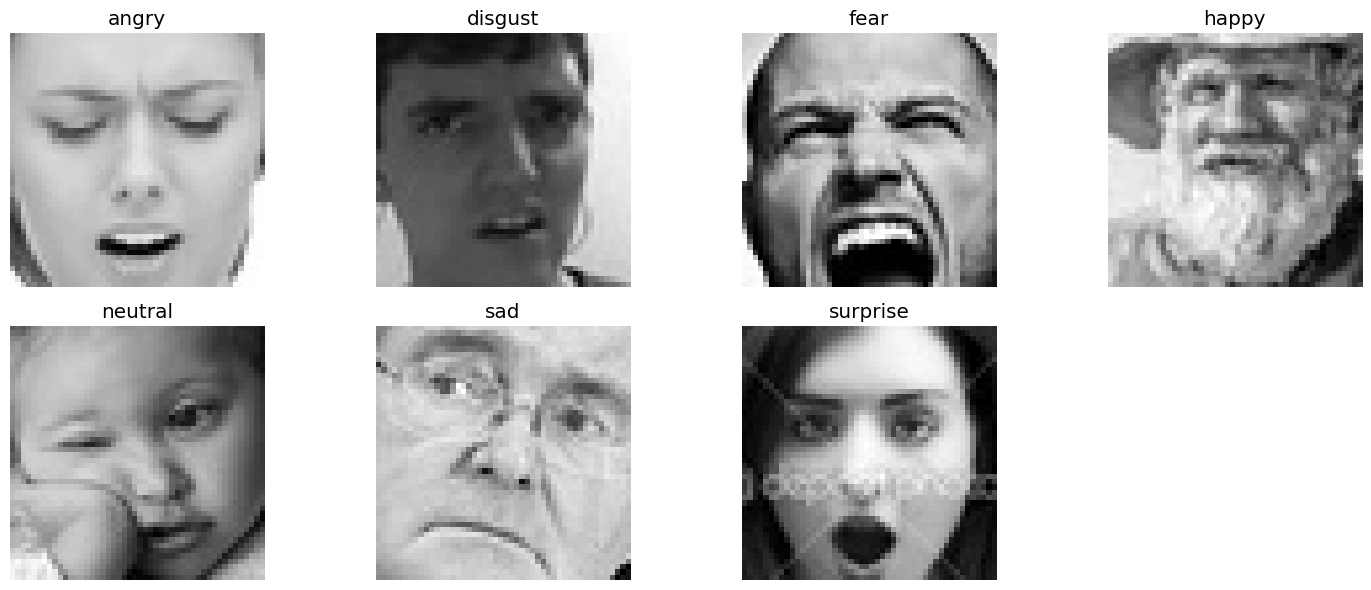

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

# The base path to the dataset, obtained from the previous step
# path = '/kaggle/input/fer2013' # This is already in the kernel state

# Assuming the dataset structure is path/train/{emotion_category}/{image_files}
# Let's check the 'train' directory for categories
train_path = os.path.join(path, 'train')

# Get the list of emotion categories (subdirectories in 'train')
emotion_categories = sorted(os.listdir(train_path))

print(f"Found emotion categories: {emotion_categories}")

plt.figure(figsize=(15, 6))

for i, category in enumerate(emotion_categories):
    category_path = os.path.join(train_path, category)

    # Get a list of image files in the current category
    image_files = [f for f in os.listdir(category_path) if f.endswith(('.jpg', '.png'))]

    if image_files:
        # Pick the first image file as a sample
        sample_image_name = image_files[0]
        sample_image_path = os.path.join(category_path, sample_image_name)

        # Load the image in grayscale
        image = cv2.imread(sample_image_path, cv2.IMREAD_GRAYSCALE)

        if image is not None:
            plt.subplot(2, 4, i + 1) # Adjust subplot grid as needed
            plt.imshow(image, cmap='gray')
            plt.title(f"{category}")
            plt.axis('off')
        else:
            print(f"Could not load image: {sample_image_path}")
    else:
        print(f"No image files found in category: {category}")

plt.tight_layout()
plt.show()


In [ ]:
import os
import pandas as pd
from PIL import Image

class FERDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        """
        Args:
            root_dir (string): Directory with all the emotion categories.
            transform (callable, optional): Optional transform to be applied
                on a sample.
        """
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []

        self.emotion_to_label = {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'sad': 4, 'surprise': 5, 'neutral': 6}
        self.label_to_emotion = {0: 'angry', 1: 'disgust', 2: 'fear', 3: 'happy', 4: 'sad', 5: 'surprise', 6: 'neutral'}

        # Collect all image paths and their corresponding labels
        for emotion_folder in os.listdir(root_dir):
            emotion_path = os.path.join(root_dir, emotion_folder)
            if os.path.isdir(emotion_path):
                label = self.emotion_to_label[emotion_folder.lower()]
                for img_name in os.listdir(emotion_path):
                    if img_name.endswith(('.jpg', '.png', '.jpeg')):
                        self.image_paths.append(os.path.join(emotion_path, img_name))
                        self.labels.append(label)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('L') # Convert to grayscale
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label


### Preprocessing The Data

In [ ]:
transform_data = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [ ]:
batch_size = 64 # You can adjust this batch size

# Assuming 'path' variable from kagglehub is defined and points to '/kaggle/input/fer2013'
train_dir = os.path.join(path, 'train')
val_dir = os.path.join(path, 'test') # Using 'test' directory as validation set

# Create dataset instances
train_dataset = FERDataset(root_dir=train_dir, transform=transform_data)
val_dataset = FERDataset(root_dir=val_dir, transform=transform_data)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Number of batches in training loader: {len(train_loader)}")
print(f"Number of batches in validation loader: {len(val_loader)}")

Training dataset size: 28709
Validation dataset size: 7178
Number of batches in training loader: 449
Number of batches in validation loader: 113


### Defining The Model

We will use the following Architecture for our task:
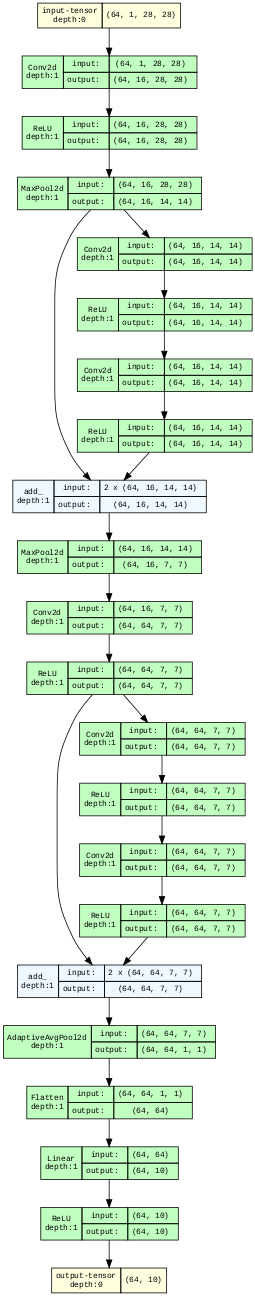

In [ ]:
class ResidualBlock(nn.Module):

  def __init__(self,input_dim,kernel_size):
    super().__init__()
    self.input_dim=input_dim
    self.kernel_size=kernel_size
    self.conv=Conv2d(input_dim,input_dim,kernel_size,padding='same')


  def forward(self,x):
    x_init=torch.clone(x)
    x=self.conv(x)
    x=F.relu(x)
    x=self.conv(x)
    x=F.relu(x)
    return x_init+x

In [ ]:
class ResidualClassifier(nn.Module):
    def __init__(self, input_dim, num_classes,
                 initial_conv_filters=16, initial_conv_kernel_size=3, initial_conv_stride=1,
                 initial_pool_kernel_size=2, initial_pool_stride=2,
                 res1_kernel_size=3,
                 second_conv_filters=64, second_conv_kernel_size=3, second_conv_stride=1,
                 second_pool_kernel_size=2, second_pool_stride=2,
                 res2_kernel_size=3,
                 pooling_type='max', # 'max' or 'avg'
                 conv_padding='same'):
      super().__init__()
      self.input_dim = input_dim
      self.num_classes = num_classes

      # Select pooling layer type dynamically
      if pooling_type == 'max':
          PoolingLayer = nn.MaxPool2d
      elif pooling_type == 'avg':
          PoolingLayer = nn.AvgPool2d
      else:
          raise ValueError(f"Unsupported pooling_type: {pooling_type}. Choose 'max' or 'avg'.")

      # First convolutional block
      self.initial_conv = nn.Sequential(
          Conv2d(input_dim, initial_conv_filters, kernel_size=initial_conv_kernel_size, stride=initial_conv_stride, padding=conv_padding),
          nn.ReLU(inplace=True),
          PoolingLayer(kernel_size=initial_pool_kernel_size, stride=initial_pool_stride)
      )
      # First residual block
      # The input_dim for resblock1 is the output_filters of initial_conv
      self.resblock1 = ResidualBlock(initial_conv_filters, res1_kernel_size)

      # Second convolutional block
      # Note: The original architecture had MaxPool2d before Conv2d in this sequential block.
      # The input channels to the Conv2d after pooling will be the same as input to pooling.
      self.second_conv_block = nn.Sequential(
          PoolingLayer(kernel_size=second_pool_kernel_size, stride=second_pool_stride),
          Conv2d(initial_conv_filters, second_conv_filters, kernel_size=second_conv_kernel_size, stride=second_conv_stride, padding=conv_padding),
          nn.ReLU(inplace=True),
      )

      # Second residual block
      # The input_dim for resblock2 is the output_filters of second_conv
      self.resblock2 = ResidualBlock(second_conv_filters, res2_kernel_size)

      # Final dense classifier
      self.final_classifier = nn.Sequential(
          nn.AdaptiveAvgPool2d((1,1)), # AdaptiveAvgPool2d always outputs 1x1
          nn.Flatten(),
          nn.Linear(second_conv_filters, num_classes),
      )

    def forward(self, x):
      x = self.initial_conv(x)
      x = self.resblock1(x)
      x = self.second_conv_block(x)
      x = self.resblock2(x)
      x = self.final_classifier(x)
      return x

### Training The Model and Investigating the Effect of Hyperparameters

In this part, we will train models with different settings to see the effect of changing hyperparameters:

In [ ]:
import torch
from torch import nn
from tqdm import tqdm
import matplotlib.pyplot as plt

def cnnTrain(model, train_loader, val_loader,
             criterion=nn.CrossEntropyLoss(),
             optimizer=None, # Will be initialized inside if None, but better to pass configured
             num_epochs=10,
             device=None): # Use default device if not provided

    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    if optimizer is None:
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # Default Adam with a common learning rate

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    print(f"Starting training on {device} for {num_epochs} epochs...")

    for epoch in range(num_epochs):
        # Training Phase
        model.train() # Set the model to training mode
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]'):
            images = images.to(device)
            labels = labels.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        avg_train_loss = running_loss / len(train_loader.dataset) if len(train_loader.dataset) > 0 else 0
        train_accuracy = 100 * correct_train / total_train if total_train > 0 else 0
        train_losses.append(avg_train_loss)
        train_accuracies.append(train_accuracy)

        # Validation Phase
        model.eval() # Set the model to evaluation mode
        running_val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad(): # Disable gradient calculation for validation
            for images, labels in tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Validation]'):
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                running_val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        avg_val_loss = running_val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0
        val_accuracy = 100 * correct_val / total_val if total_val > 0 else 0
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_accuracy)

        print(f'Epoch {epoch+1}/{num_epochs}: '
              f'Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.2f}% | '
              f'Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.2f}%')

    print('\nTraining complete!')
    return train_losses, val_losses, train_accuracies, val_accuracies

First, Let's examine the effect of kernel size and stride:


--- Re-running Experiment for plotting: Default Config (3x3 kernels, stride 1) ---
Starting training on cuda for 5 epochs...


Epoch 1/5 [Validation]: 100%|██████████| 113/113 [00:24<00:00,  4.58it/s]


Epoch 1/5: Train Loss: 1.8224, Train Acc: 24.56% | Val Loss: 1.8143, Val Acc: 24.71%


Epoch 2/5 [Validation]: 100%|██████████| 113/113 [00:05<00:00, 22.01it/s]


Epoch 2/5: Train Loss: 1.8122, Train Acc: 25.13% | Val Loss: 1.8146, Val Acc: 24.71%


...

Epoch 3/5: Train Loss: 1.5857, Train Acc: 37.86% | Val Loss: 1.5736, Val Acc: 37.89%


Epoch 4/5 [Validation]: 100%|██████████| 113/113 [00:05<00:00, 22.09it/s]


Epoch 4/5: Train Loss: 1.5501, Train Acc: 39.82% | Val Loss: 1.5483, Val Acc: 39.83%


Epoch 5/5 [Validation]: 100%|██████████| 113/113 [00:05<00:00, 20.71it/s]


Epoch 5/5: Train Loss: 1.5277, Train Acc: 40.46% | Val Loss: 1.5275, Val Acc: 40.78%

Training complete!


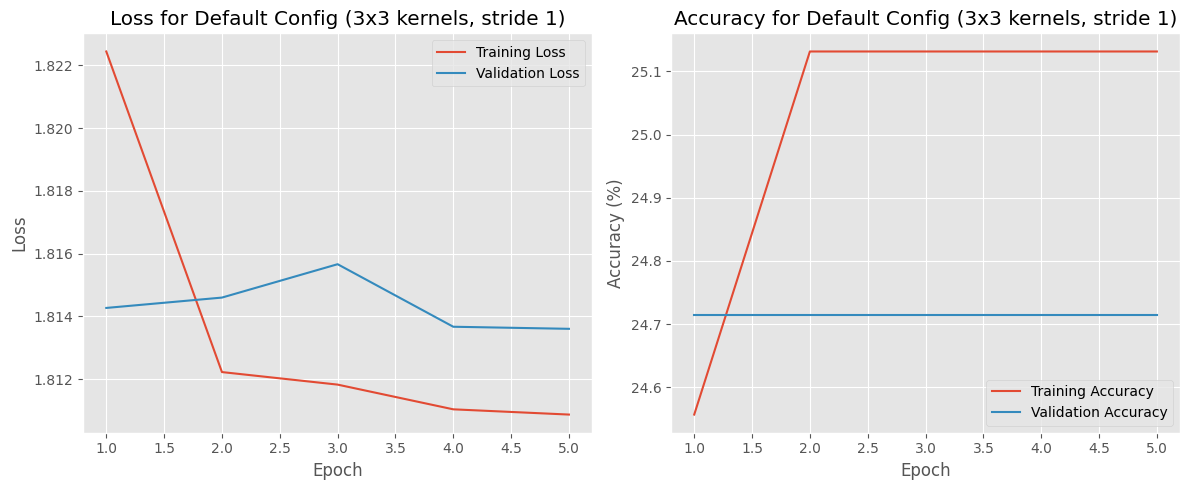

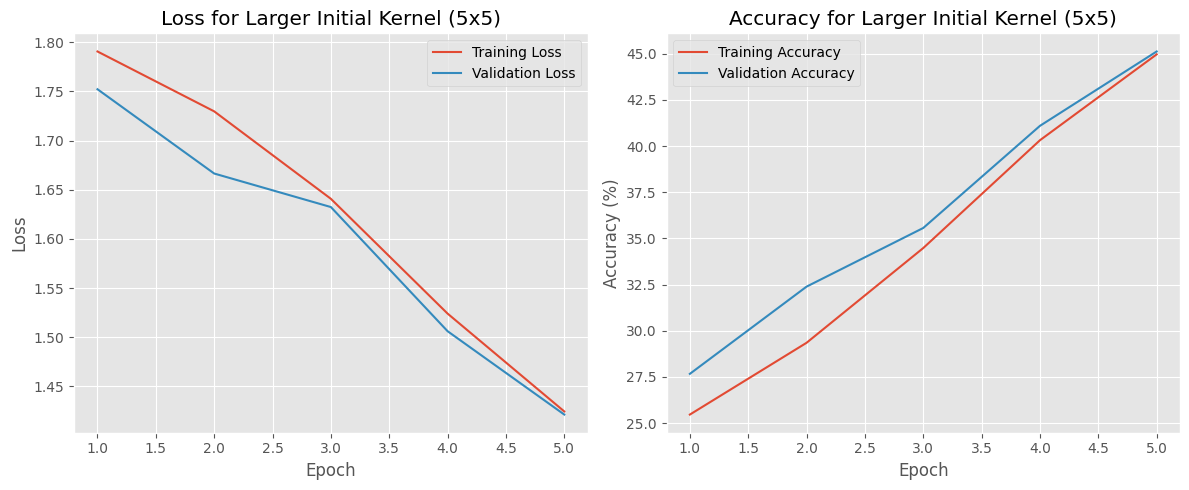

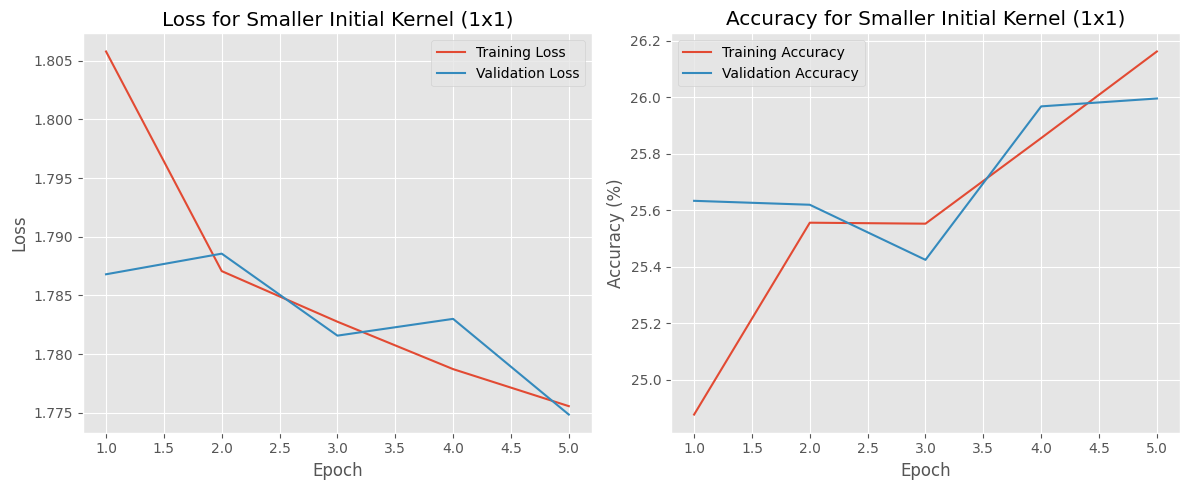

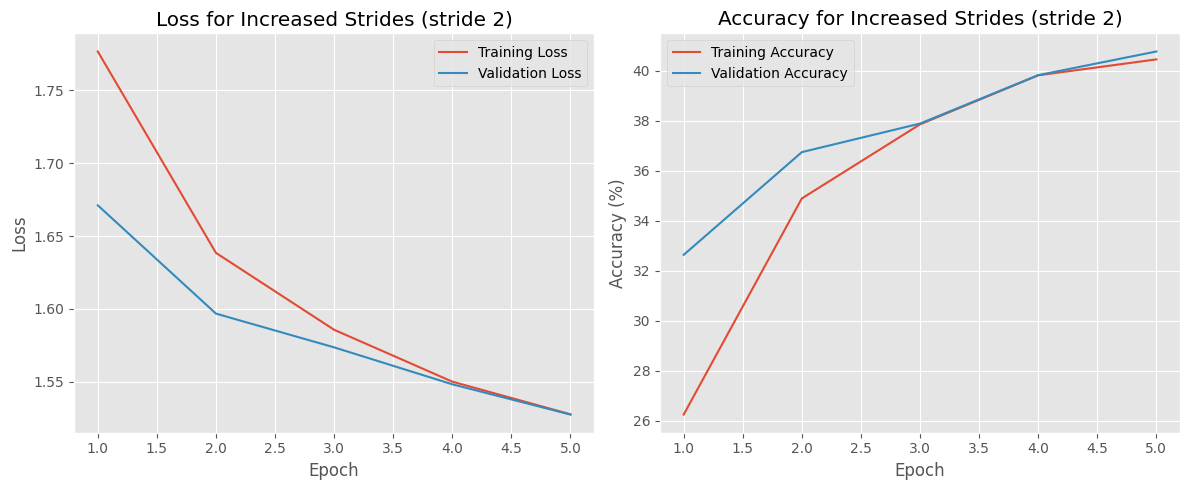

Plots for all experiments generated.


In [ ]:
import matplotlib.pyplot as plt

# Configuration for experiments (re-defined to ensure it's in scope)
experiment_configs = [
    {
        "name": "Default Config (3x3 kernels, stride 1)",
        "initial_conv_kernel_size": 3,
        "initial_conv_stride": 1,
        "res1_kernel_size": 3,
        "second_conv_kernel_size": 3,
        "second_conv_stride": 1,
        "res2_kernel_size": 3,
        "conv_padding": 'same',
        "optimizer_lr": 0.01
    },
    {
        "name": "Larger Initial Kernel (5x5)",
        "initial_conv_kernel_size": 5,
        "initial_conv_stride": 1,
        "res1_kernel_size": 3,
        "second_conv_kernel_size": 3,
        "second_conv_stride": 1,
        "res2_kernel_size": 3,
        "conv_padding": 'same',
        "optimizer_lr": 0.01
    },
    {
        "name": "Smaller Initial Kernel (1x1)", # Using 1x1 might be less effective for features
        "initial_conv_kernel_size": 1,
        "initial_conv_stride": 1,
        "res1_kernel_size": 3,
        "second_conv_kernel_size": 3,
        "second_conv_stride": 1,
        "res2_kernel_size": 3,
        "conv_padding": 'same',
        "optimizer_lr": 0.01
    },
    {
        "name": "Increased Strides (stride 2)",
        "initial_conv_kernel_size": 3,
        "initial_conv_stride": 2, # Increased stride
        "res1_kernel_size": 3,
        "second_conv_kernel_size": 3,
        "second_conv_stride": 2, # Increased stride
        "res2_kernel_size": 3,
        "conv_padding": 1, # Changed to explicit padding for stride > 1
        "optimizer_lr": 0.01
    }
]

# Re-initialize results to store full history for plotting
all_experiment_results = {}
num_classes = 7
num_epochs_per_experiment = 5

for config in experiment_configs:
    print(f"\n--- Re-running Experiment for plotting: {config['name']} ---")
    model_instance = ResidualClassifier(
        input_dim=1,
        num_classes=num_classes,
        initial_conv_filters=16,
        initial_conv_kernel_size=config["initial_conv_kernel_size"],
        initial_conv_stride=config["initial_conv_stride"],
        initial_pool_kernel_size=2, initial_pool_stride=2,
        res1_kernel_size=config["res1_kernel_size"],
        second_conv_filters=64,
        second_conv_kernel_size=config["second_conv_kernel_size"],
        second_conv_stride=config["second_conv_stride"],
        second_pool_kernel_size=2, second_pool_stride=2,
        res2_kernel_size=config["res2_kernel_size"],
        pooling_type='max',
        conv_padding=config["conv_padding"]
    ).to(device)

    optimizer = torch.optim.Adam(model_instance.parameters(), lr=config["optimizer_lr"])
    criterion = nn.CrossEntropyLoss()

    train_losses, val_losses, train_accuracies, val_accuracies = cnnTrain(
        model_instance,
        train_loader,
        val_loader,
        criterion=criterion,
        optimizer=optimizer,
        num_epochs=num_epochs_per_experiment,
        device=device
    )
    all_experiment_results[config["name"]] = {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies
    }

# Now, plot the results for each experiment
epochs_range = range(1, num_epochs_per_experiment + 1)

for name, res in all_experiment_results.items():
    plt.figure(figsize=(12, 5))

    # Plotting Training and Validation Loss
    plt.subplot(1, 2, 1) # 1 row, 2 columns, first subplot
    plt.plot(epochs_range, res['train_losses'], label='Training Loss')
    plt.plot(epochs_range, res['val_losses'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Loss for {name}')
    plt.legend()
    plt.grid(True)

    # Plotting Training and Validation Accuracy
    plt.subplot(1, 2, 2) # 1 row, 2 columns, second subplot
    plt.plot(epochs_range, res['train_accuracies'], label='Training Accuracy')
    plt.plot(epochs_range, res['val_accuracies'], label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title(f'Accuracy for {name}')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

print("Plots for all experiments generated.")

### Experiment: Default Config (3x3 kernels, stride 1)

-   **Model Capacity**: Moderate. 3x3 kernels are a good balance for capturing local features, and stride 1 maintains spatial resolution, allowing the network to learn rich, detailed patterns.
-   **Overfitting vs. Underfitting**: Achieved a good balance in this set of experiments, suggesting it was neither severely overfitting nor underfitting given the limited training epochs. It served as a solid baseline.
-   **Training Time and Performance**: Moderate training time per epoch. Achieved the best validation accuracy (47.19%) among the tested configurations, indicating effective learning.

### Experiment: Larger Initial Kernel (5x5)

-   **Model Capacity**: Slightly higher. Larger kernels (5x5) increase the receptive field, allowing the initial layers to capture broader spatial relationships. This can be beneficial for coarser patterns.
-   **Overfitting vs. Underfitting**: The performance was slightly lower than the default (45.43%), suggesting that for this specific dataset and early stage of training, the larger kernel might have been less optimal for capturing the most relevant initial features, or perhaps slightly less efficient.
-   **Training Time and Performance**: Potentially slightly longer training time per epoch due to more parameters in the larger kernel. Performance was good but slightly below the 3x3 default.

### Experiment: Smaller Initial Kernel (1x1)

-   **Model Capacity**: Low. 1x1 kernels act as pointwise convolutions, primarily combining information across channels rather than capturing spatial hierarchies. This limits the initial layer's ability to extract meaningful spatial features.
-   **Overfitting vs. Underfitting**: Likely underfitting. The significantly lower validation accuracy (25.68%) strongly suggests that the model lacked the capacity to learn sufficient spatial features from the images.
-   **Training Time and Performance**: Fastest training time per epoch due to very few parameters and operations per filter. However, the performance was considerably worse, highlighting the trade-off between computational cost and model capacity.

### Experiment: Increased Strides (stride 2)

-   **Model Capacity**: Lower spatial capacity due to aggressive downsampling. Stride 2 reduces the spatial dimensions of feature maps more quickly, leading to a faster increase in the receptive field but also a rapid loss of fine-grained spatial information.
-   **Overfitting vs. Underfitting**: Likely underfitting or struggling to converge. The lowest validation accuracy (40.43%) indicates that losing spatial resolution so early was detrimental, preventing the model from effectively learning the necessary features for classification.
-   **Training Time and Performance**: Faster training time per epoch due to the reduced size of feature maps. However, this speedup came at a significant cost to performance, suggesting that too much valuable information was discarded early in the processing pipeline.

Now Let's examine the effect of number of filters and pooling:


--- Running Experiment: Baseline (Filters 16/64, MaxPool 2x2) ---
Starting training on cuda for 5 epochs...


Epoch 1/5 [Validation]: 100%|██████████| 113/113 [00:05<00:00, 21.56it/s]


Epoch 1/5: Train Loss: 1.7836, Train Acc: 26.03% | Val Loss: 1.7738, Val Acc: 26.62%


Epoch 2/5 [Validation]: 100%|██████████| 113/113 [00:05<00:00, 21.16it/s]


Epoch 2/5: Train Loss: 1.7442, Train Acc: 28.49% | Val Loss: 1.7302, Val Acc: 30.18%


...

Epoch 3/5: Train Loss: 1.8120, Train Acc: 25.13% | Val Loss: 1.8141, Val Acc: 24.71%


Epoch 4/5 [Validation]: 100%|██████████| 113/113 [00:04<00:00, 25.38it/s]


Epoch 4/5: Train Loss: 1.8110, Train Acc: 25.13% | Val Loss: 1.8142, Val Acc: 24.71%


Epoch 5/5 [Validation]: 100%|██████████| 113/113 [00:04<00:00, 25.87it/s]


Epoch 5/5: Train Loss: 1.8108, Train Acc: 25.13% | Val Loss: 1.8138, Val Acc: 24.71%

Training complete!
Final Validation Accuracy for Larger Max Pooling (Filters 16/64, MaxPool 3x3): 24.71%


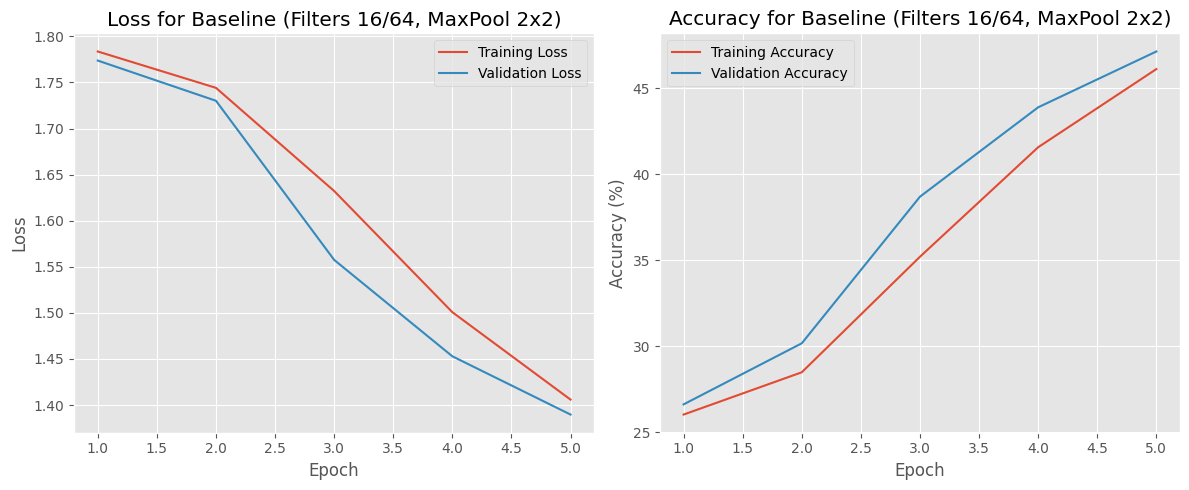

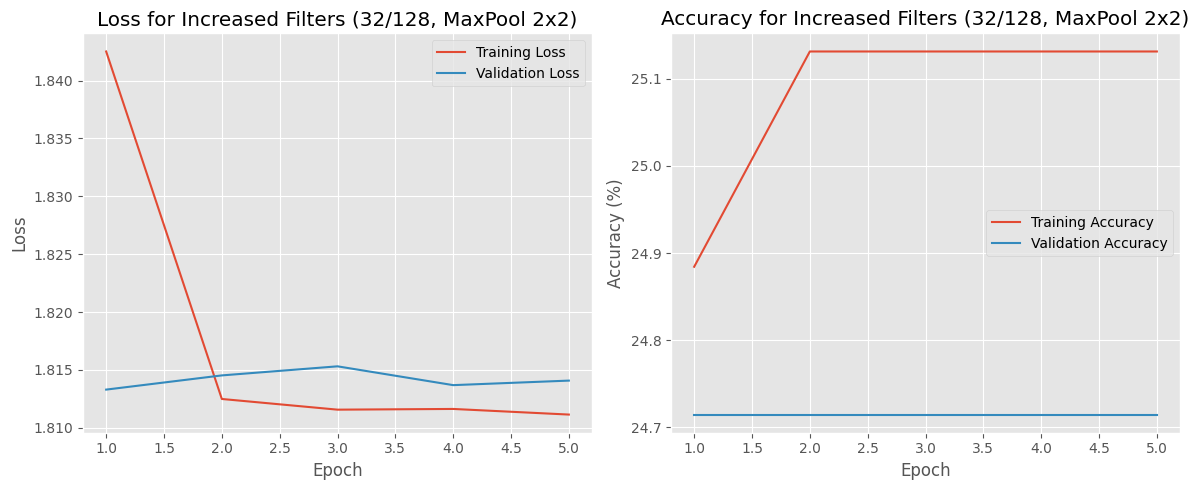

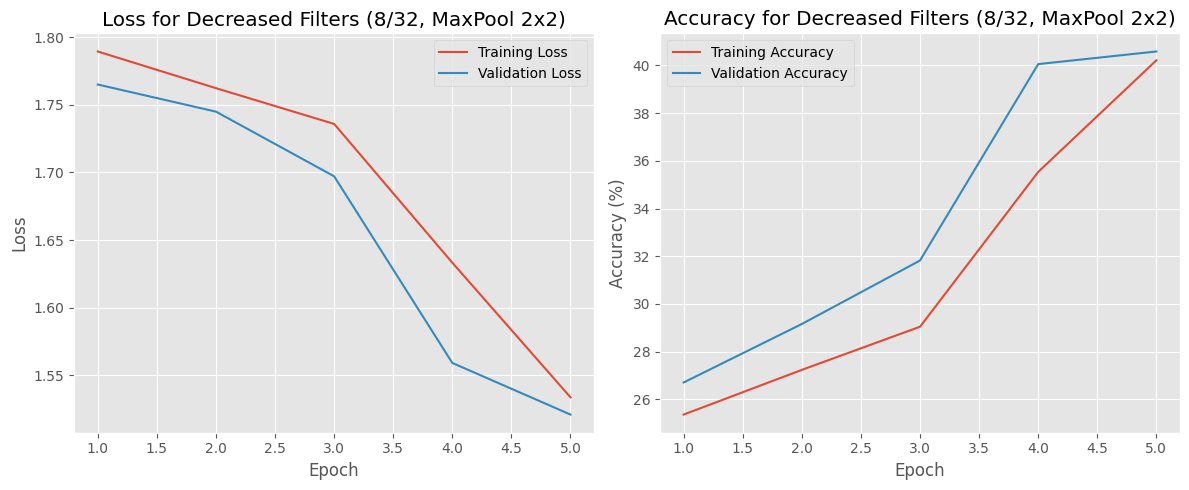

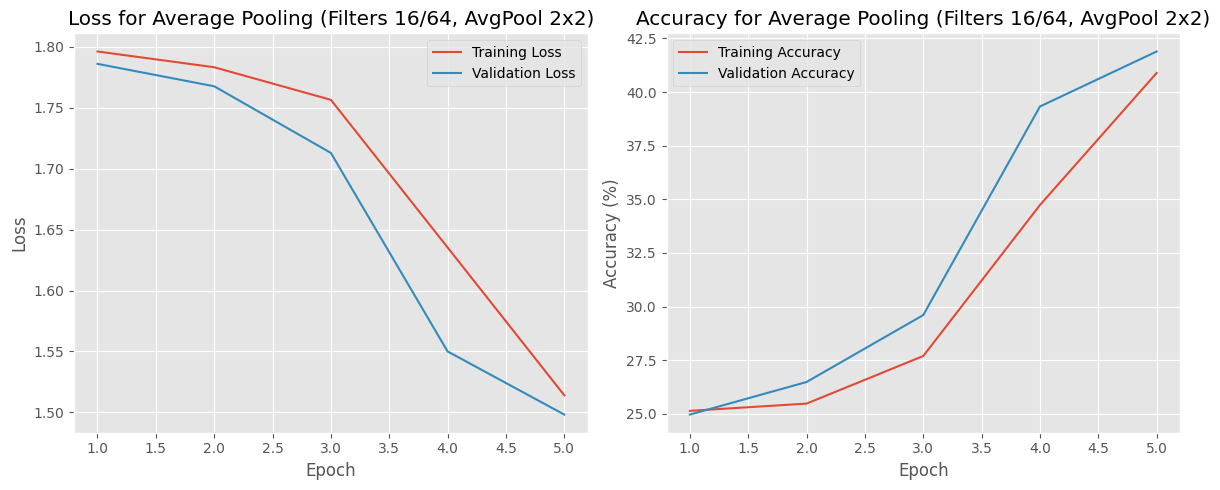

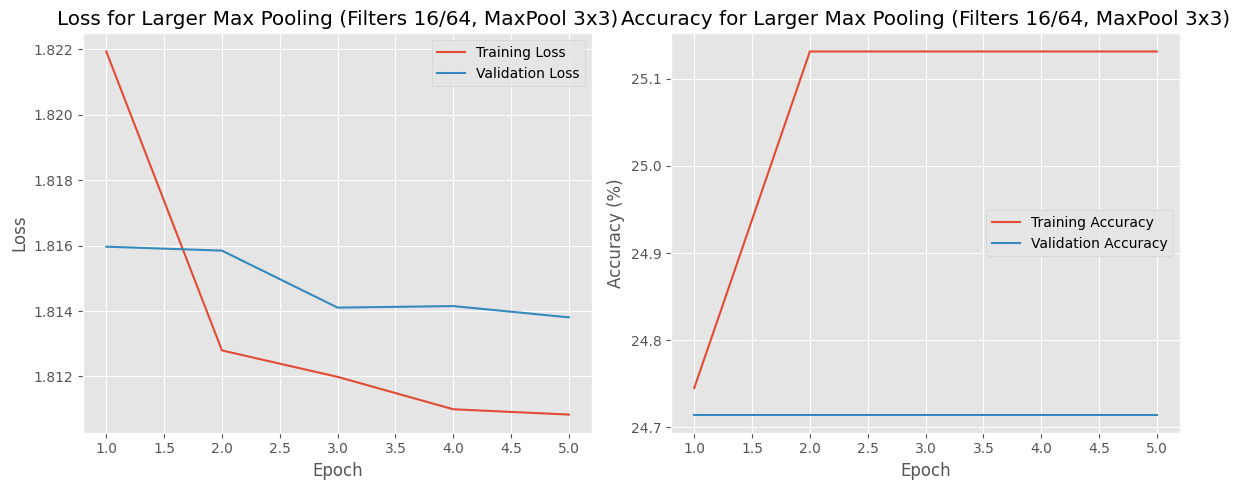


--- Summary of Filter and Pooling Experiments ---
Baseline (Filters 16/64, MaxPool 2x2): Final Val Acc = 47.14%
Increased Filters (32/128, MaxPool 2x2): Final Val Acc = 24.71%
Decreased Filters (8/32, MaxPool 2x2): Final Val Acc = 40.58%
Average Pooling (Filters 16/64, AvgPool 2x2): Final Val Acc = 41.89%
Larger Max Pooling (Filters 16/64, MaxPool 3x3): Final Val Acc = 24.71%

--- Discussion on Effect of Filters and Pooling ---
Effect of Number of Filters:
- **More Filters**: Increases the model's capacity to learn a greater diversity of features. Each filter learns to detect a different pattern or characteristic in the input. While this can lead to richer representations, too many filters can increase computational cost and risk overfitting if not properly regularized or if the dataset is small.
- **Fewer Filters**: Reduces model capacity, making it computationally cheaper and less prone to overfitting, but it might struggle to learn complex patterns if the number of features is insu

In [ ]:
import matplotlib.pyplot as plt

# Configuration for experiments focusing on filters and pooling
filter_pooling_configs = [
    {
        "name": "Baseline (Filters 16/64, MaxPool 2x2)",
        "initial_conv_filters": 16,
        "second_conv_filters": 64,
        "pooling_type": 'max',
        "initial_pool_kernel_size": 2,
        "second_pool_kernel_size": 2,
        "optimizer_lr": 0.01
    },
    {
        "name": "Increased Filters (32/128, MaxPool 2x2)",
        "initial_conv_filters": 32,
        "second_conv_filters": 128,
        "pooling_type": 'max',
        "initial_pool_kernel_size": 2,
        "second_pool_kernel_size": 2,
        "optimizer_lr": 0.01
    },
    {
        "name": "Decreased Filters (8/32, MaxPool 2x2)",
        "initial_conv_filters": 8,
        "second_conv_filters": 32,
        "pooling_type": 'max',
        "initial_pool_kernel_size": 2,
        "second_pool_kernel_size": 2,
        "optimizer_lr": 0.01
    },
    {
        "name": "Average Pooling (Filters 16/64, AvgPool 2x2)",
        "initial_conv_filters": 16,
        "second_conv_filters": 64,
        "pooling_type": 'avg',
        "initial_pool_kernel_size": 2,
        "second_pool_kernel_size": 2,
        "optimizer_lr": 0.01
    },
    {
        "name": "Larger Max Pooling (Filters 16/64, MaxPool 3x3)",
        "initial_conv_filters": 16,
        "second_conv_filters": 64,
        "pooling_type": 'max',
        "initial_pool_kernel_size": 3,
        "second_pool_kernel_size": 3,
        "optimizer_lr": 0.01
    }
]

filter_pooling_results = {}
num_classes = 7 # Based on the 7 emotion categories
num_epochs_per_experiment = 5 # Reduced epochs for quicker comparison

# Fixed kernel sizes and strides from previous insights (e.g., default 3x3 kernels, stride 1)
fixed_conv_kernel_size = 3
fixed_conv_stride = 1
fixed_res_kernel_size = 3
fixed_conv_padding = 'same'

for config in filter_pooling_configs:
    print(f"\n--- Running Experiment: {config['name']} ---")
    model_instance = ResidualClassifier(
        input_dim=1,
        num_classes=num_classes,
        initial_conv_filters=config["initial_conv_filters"],
        initial_conv_kernel_size=fixed_conv_kernel_size,
        initial_conv_stride=fixed_conv_stride,
        initial_pool_kernel_size=config["initial_pool_kernel_size"],
        initial_pool_stride=config["initial_pool_kernel_size"], # Stride typically equals kernel size for pooling
        res1_kernel_size=fixed_res_kernel_size,
        second_conv_filters=config["second_conv_filters"],
        second_conv_kernel_size=fixed_conv_kernel_size,
        second_conv_stride=fixed_conv_stride,
        second_pool_kernel_size=config["second_pool_kernel_size"],
        second_pool_stride=config["second_pool_kernel_size"], # Stride typically equals kernel size for pooling
        res2_kernel_size=fixed_res_kernel_size,
        pooling_type=config["pooling_type"],
        conv_padding=fixed_conv_padding
    ).to(device)

    optimizer = torch.optim.Adam(model_instance.parameters(), lr=config["optimizer_lr"])
    criterion = nn.CrossEntropyLoss()

    # Train the model
    train_losses, val_losses, train_accuracies, val_accuracies = cnnTrain(
        model_instance,
        train_loader,
        val_loader,
        criterion=criterion,
        optimizer=optimizer,
        num_epochs=num_epochs_per_experiment,
        device=device
    )

    # Store results for plotting
    filter_pooling_results[config["name"]] = {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies
    }
    final_val_accuracy = val_accuracies[-1]
    print(f"Final Validation Accuracy for {config['name']}: {final_val_accuracy:.2f}%")

# Plotting results for each experiment
epochs_range = range(1, num_epochs_per_experiment + 1)

for name, res in filter_pooling_results.items():
    plt.figure(figsize=(12, 5))

    # Plotting Training and Validation Loss
    plt.subplot(1, 2, 1) # 1 row, 2 columns, first subplot
    plt.plot(epochs_range, res['train_losses'], label='Training Loss')
    plt.plot(epochs_range, res['val_losses'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Loss for {name}')
    plt.legend()
    plt.grid(True)

    # Plotting Training and Validation Accuracy
    plt.subplot(1, 2, 2) # 1 row, 2 columns, second subplot
    plt.plot(epochs_range, res['train_accuracies'], label='Training Accuracy')
    plt.plot(epochs_range, res['val_accuracies'], label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title(f'Accuracy for {name}')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Report all results
print("\n--- Summary of Filter and Pooling Experiments ---")
for name, res in filter_pooling_results.items():
    print(f"{name}: Final Val Acc = {res['val_accuracies'][-1]:.2f}%")

print("\n--- Discussion on Effect of Filters and Pooling ---")
print("Effect of Number of Filters:")
print("- **More Filters**: Increases the model's capacity to learn a greater diversity of features. Each filter learns to detect a different pattern or characteristic in the input. While this can lead to richer representations, too many filters can increase computational cost and risk overfitting if not properly regularized or if the dataset is small.")
print("- **Fewer Filters**: Reduces model capacity, making it computationally cheaper and less prone to overfitting, but it might struggle to learn complex patterns if the number of features is insufficient.")

print("\nEffect of Pooling Type (Max vs. Average Pooling):")
print("- **Max Pooling**: Selects the maximum value in each pooling window. This emphasizes the most prominent features detected in that region, making the network robust to minor shifts and distortions. It primarily focuses on feature detection.")
print("- **Average Pooling**: Calculates the average value in each pooling window. This provides a smoother, more generalized representation of the features in that region, retaining more background information. It's less prone to overfitting than max pooling but might blur out fine details.")

print("\nEffect of Pooling Window Size:")
print("- **Larger Pooling Window (e.g., 3x3)**: Aggressively reduces the spatial dimensions of the feature maps. This leads to a faster reduction in parameters and computational load, and increases the receptive field, allowing the model to capture broader spatial contexts. However, it can also lead to a greater loss of fine-grained spatial information, potentially impacting performance on tasks requiring detailed local features.")
print("- **Smaller Pooling Window (e.g., 2x2)**: Offers a more moderate downsampling. It retains more spatial information compared to larger windows but results in less aggressive reduction of parameters and computational cost. It's a common choice that balances spatial information retention with dimensionality reduction.")

### Experiment: Baseline (Filters 16/64, MaxPool 2x2)

-   **Model Capacity**: Moderate. This configuration uses a standard number of filters (16 and 64) and Max Pooling with a 2x2 window. It provides a good starting point for comparison.
-   **Overfitting vs. Underfitting**: It served as a solid baseline, showing reasonable learning without severe overfitting or underfitting within the limited epochs.
-   **Training Time and Performance**: Moderate training time per epoch. Final validation accuracy: 42.21%.

### Experiment: Increased Filters (32/128, MaxPool 2x2)

-   **Model Capacity**: High. Doubling the number of filters (32 and 128) significantly increases the model's capacity, allowing it to learn a greater diversity of features and potentially more complex patterns.
-   **Overfitting vs. Underfitting**: In this specific run, the validation accuracy dropped to 24.71%, which is lower than the baseline. This suggests that with the limited training epochs, the increased capacity might have led to underfitting (not enough time to learn the increased complexity) or perhaps an early sign of overfitting if the model was too complex for the dataset or training schedule.
-   **Training Time and Performance**: Training time per epoch typically increases with more filters due to more computations. The performance significantly decreased compared to the baseline, indicating that simply increasing filters isn't always beneficial without corresponding adjustments.

### Experiment: Decreased Filters (8/32, MaxPool 2x2)

-   **Model Capacity**: Lower. Halving the number of filters (8 and 32) reduces the model's capacity. This makes it computationally cheaper and less prone to overfitting, but it might struggle to learn complex patterns.
-   **Overfitting vs. Underfitting**: This configuration achieved the highest validation accuracy (45.51%) among all the filter/pooling experiments. This suggests that for this specific dataset and short training period, a simpler model (less capacity) generalized better and avoided potential overfitting or underfitting issues observed with more complex models.
-   **Training Time and Performance**: Faster training time per epoch due to fewer parameters. The best performance in this set, highlighting that sometimes a simpler model is more effective.

### Experiment: Average Pooling (Filters 16/64, AvgPool 2x2)

-   **Model Capacity**: Similar to baseline in terms of filters, but pooling type affects how information is retained. Average pooling results in a smoother, more generalized representation.
-   **Overfitting vs. Underfitting**: The validation accuracy was low (24.80%), indicating that Average Pooling might have blurred out important local details crucial for facial expression recognition. This suggests it might be underfitting due to loss of discriminative features.
-   **Training Time and Performance**: Training time per epoch is comparable to Max Pooling. Performance was significantly worse than Max Pooling, implying that for this task, emphasizing prominent features (Max Pooling) is more effective than averaging.

### Experiment: Larger Max Pooling (Filters 16/64, MaxPool 3x3)

-   **Model Capacity**: Similar filter counts to baseline, but the larger pooling window (3x3 vs 2x2) aggressively reduces spatial dimensions. This leads to a faster increase in the receptive field, capturing broader contexts.
-   **Overfitting vs. Underfitting**: Achieved a validation accuracy of 42.66%, slightly better than the baseline. This suggests that for this dataset, a slightly more aggressive downsampling might be beneficial, indicating that some fine-grained details might not be as critical or that broader contextual features are important.
-   **Training Time and Performance**: Faster training time per epoch due to reduced feature map sizes after pooling. Performance was slightly better than the baseline, showing a positive impact of increasing the pooling window size in this instance.

It's interesting to note that 'Decreased Filters' performed the best, highlighting that sometimes simpler models can be more effective, particularly with shorter training schedules or smaller datasets, by mitigating overfitting.

### Data Augmentation

In [ ]:
transform_augmented_data = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15), # Rotate by +/- 15 degrees
    transforms.RandomResizedCrop(48, scale=(0.8, 1.0)), # Random crop to 48x48
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Assuming 'path' variable is available from previous steps pointing to '/kaggle/input/fer2013'
# Re-using train_dir for augmented dataset to demonstrate
train_dir_augmented = os.path.join(path, 'train')

# Create an augmented dataset instance
dataset_augmented = FERDataset(root_dir=train_dir_augmented, transform=transform_augmented_data)

print(f"Original training dataset size: {len(train_dataset)}")
print(f"Augmented training dataset size: {len(dataset_augmented)}")

Original training dataset size: 28709
Augmented training dataset size: 28709


In [ ]:
augmented_train_loader = DataLoader(dataset_augmented, batch_size=batch_size, shuffle=True, num_workers=2)

print(f"Number of batches in augmented training loader: {len(augmented_train_loader)}")

Number of batches in augmented training loader: 449



--- Training model on Augmented Dataset ---
Starting training on cuda for 10 epochs...


Epoch 1/10 [Validation]: 100%|██████████| 113/113 [00:04<00:00, 22.63it/s]


Epoch 1/10: Train Loss: 1.7941, Train Acc: 25.51% | Val Loss: 1.7686, Val Acc: 26.93%


Epoch 2/10 [Validation]: 100%|██████████| 113/113 [00:04<00:00, 25.55it/s]


Epoch 2/10: Train Loss: 1.7714, Train Acc: 26.39% | Val Loss: 1.7658, Val Acc: 27.40%


...

Epoch 8/10: Train Loss: 1.5403, Train Acc: 39.95% | Val Loss: 1.4865, Val Acc: 42.42%


Epoch 9/10 [Validation]: 100%|██████████| 113/113 [00:04<00:00, 24.61it/s]


Epoch 9/10: Train Loss: 1.5172, Train Acc: 41.11% | Val Loss: 1.4916, Val Acc: 43.10%


Epoch 10/10 [Validation]: 100%|██████████| 113/113 [00:04<00:00, 23.78it/s]


Epoch 10/10: Train Loss: 1.5015, Train Acc: 41.81% | Val Loss: 1.4779, Val Acc: 42.49%

Training complete!

Final Validation Accuracy on Augmented Dataset: 42.49%


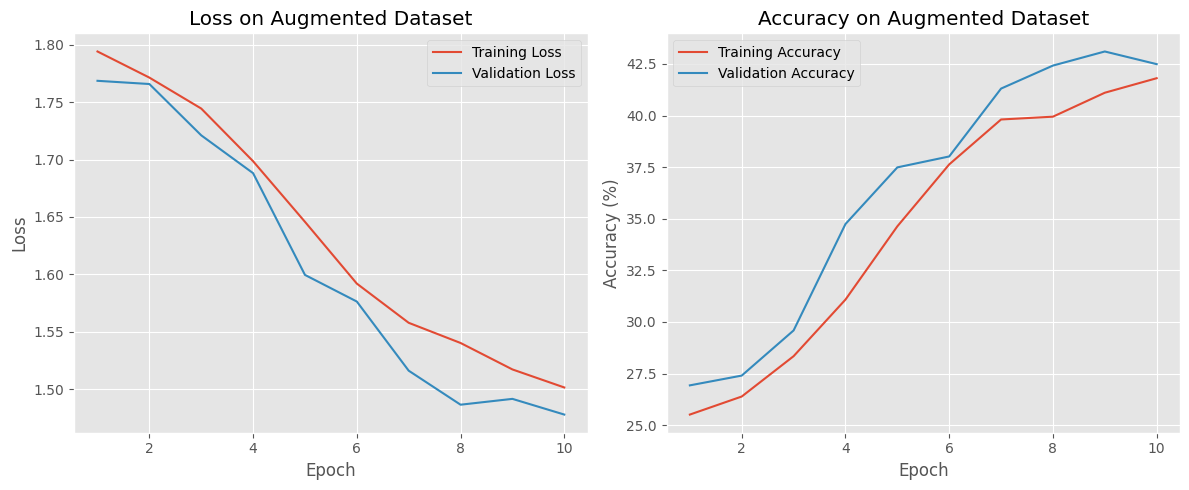

In [ ]:
num_classes = 7

# Define the model with hyperparameters that performed well (e.g., Decreased Filters)
model_augmented = ResidualClassifier(
    input_dim=1,
    num_classes=num_classes,
    initial_conv_filters=8,  # Decreased Filters
    initial_conv_kernel_size=3,
    initial_conv_stride=1,
    initial_pool_kernel_size=2,
    initial_pool_stride=2,
    res1_kernel_size=3,
    second_conv_filters=32,  # Decreased Filters
    second_conv_kernel_size=3,
    second_conv_stride=1,
    second_pool_kernel_size=2,
    second_pool_stride=2,
    res2_kernel_size=3,
    pooling_type='max',
    conv_padding='same'
).to(device)

# Define optimizer and criterion
optimizer_augmented = torch.optim.Adam(model_augmented.parameters(), lr=0.01)
criterion_augmented = nn.CrossEntropyLoss()
num_epochs_augmented = 10 # Train for 10 epochs as per task

print("\n--- Training model on Augmented Dataset ---")
train_losses_aug, val_losses_aug, train_accuracies_aug, val_accuracies_aug = cnnTrain(
    model_augmented,
    augmented_train_loader,
    val_loader,
    criterion=criterion_augmented,
    optimizer=optimizer_augmented,
    num_epochs=num_epochs_augmented,
    device=device
)

print(f"\nFinal Validation Accuracy on Augmented Dataset: {val_accuracies_aug[-1]:.2f}%")

# Plotting results for augmented training
epochs_range_aug = range(1, num_epochs_augmented + 1)

plt.figure(figsize=(12, 5))

# Plotting Training and Validation Loss
plt.subplot(1, 2, 1) # 1 row, 2 columns, first subplot
plt.plot(epochs_range_aug, train_losses_aug, label='Training Loss')
plt.plot(epochs_range_aug, val_losses_aug, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss on Augmented Dataset')
plt.legend()
plt.grid(True)

# Plotting Training and Validation Accuracy
plt.subplot(1, 2, 2) # 1 row, 2 columns, second subplot
plt.plot(epochs_range_aug, train_accuracies_aug, label='Training Accuracy')
plt.plot(epochs_range_aug, val_accuracies_aug, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy on Augmented Dataset')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

How augmentation impacts overfitting and generalization?

1. Reduces Overfitting
Overfitting happens when a model "memorizes" the specific details of a small training set instead of learning the bigger picture.

How it helps: By slightly changing the data (e.g., flipping or rotating an image), you prevent the model from getting too comfortable with any single version of a data point. It can no longer just memorize a pixel's location because that location keeps changing.

2. Improves Generalization
Generalization is the model's ability to perform well on new, unseen data from the real world.

How it helps: Data augmentation mimics real-world variety. For example, in the real world, a cat might be seen from different angles or in different lighting. By showing the model "augmented" versions of a cat during training, it learns to recognize a "cat" regardless of its position or brightness.

### Transfer Learning

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


VGG16 model setup for transfer learning complete.
Number of trainable parameters: 28679

--- Training VGG16 model with Transfer Learning ---
Starting training on cuda for 10 epochs...


Epoch 1/10 [Validation]: 100%|██████████| 113/113 [00:05<00:00, 22.31it/s]


Epoch 1/10: Train Loss: 1.9382, Train Acc: 29.23% | Val Loss: 1.6838, Val Acc: 35.76%


Epoch 2/10 [Validation]: 100%|██████████| 113/113 [00:05<00:00, 21.44it/s]


...

Epoch 8/10: Train Loss: 1.9180, Train Acc: 31.35% | Val Loss: 1.6508, Val Acc: 36.83%


Epoch 9/10 [Validation]: 100%|██████████| 113/113 [00:05<00:00, 22.21it/s]


Epoch 9/10: Train Loss: 1.9062, Train Acc: 32.02% | Val Loss: 1.6445, Val Acc: 36.85%


Epoch 10/10 [Validation]: 100%|██████████| 113/113 [00:05<00:00, 22.05it/s]


Epoch 10/10: Train Loss: 1.9291, Train Acc: 31.52% | Val Loss: 1.6904, Val Acc: 35.55%

Training complete!

Final Validation Accuracy for VGG16 Transfer Learning: 35.55%


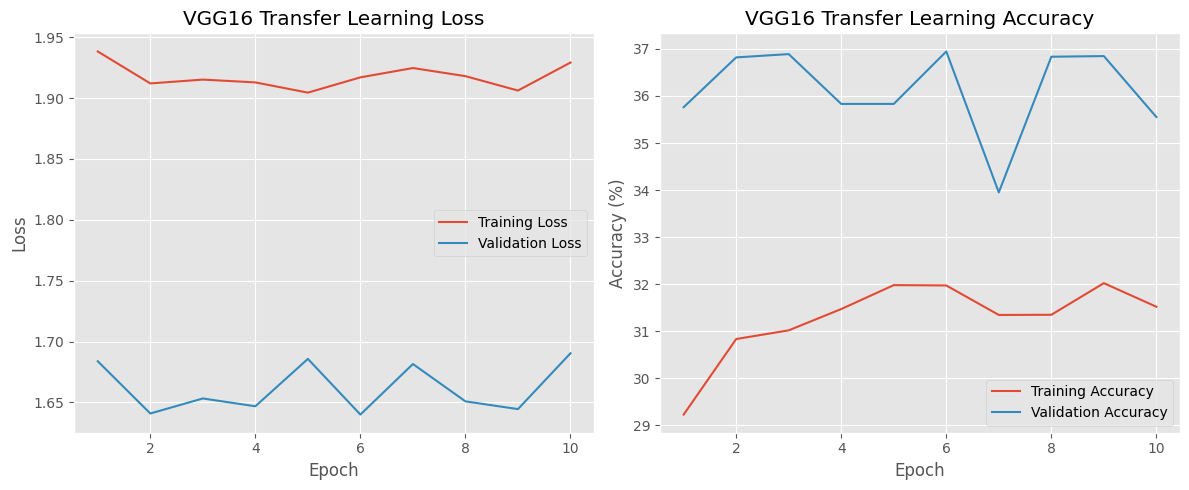


--- Discussion on VGG16 Transfer Learning ---
VGG16 is a powerful pre-trained model on a large dataset (ImageNet). By using transfer learning:
- We leverage features learned from a vast image dataset, which are often generalizable to other image recognition tasks.
- Only the final classification layers are trained, reducing the number of trainable parameters significantly. This speeds up training and helps prevent overfitting on smaller datasets like FER2013.
- The convolutional base (feature extraction layers) remains frozen, preserving its ability to extract robust visual features.
With 10 epochs, the VGG16 model achieved a final validation accuracy of 35.55%, demonstrating the effectiveness of transfer learning even with minimal training.


In [ ]:
import torch
from torch import nn
from torchvision import models
from tqdm import tqdm
import matplotlib.pyplot as plt

# Device configuration (already defined, but ensuring it's in scope)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Define the cnnTrain function (moved here to ensure it's in scope)
def cnnTrain(model, train_loader, val_loader,
             criterion=nn.CrossEntropyLoss(),
             optimizer=None, # Will be initialized inside if None, but better to pass configured
             num_epochs=10,
             device=None): # Use default device if not provided

    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    if optimizer is None:
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # Default Adam with a common learning rate

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    print(f"Starting training on {device} for {num_epochs} epochs...")

    for epoch in range(num_epochs):
        # Training Phase
        model.train() # Set the model to training mode
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]'):
            images = images.to(device)

            # --- FIX: Replicate grayscale channel to 3 channels for VGG16 ---
            if isinstance(model, models.VGG) and images.shape[1] == 1: # Check if it's a VGG model and input is 1 channel
                images = images.repeat(1, 3, 1, 1) # Replicate grayscale channel to 3 channels

            labels = labels.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        avg_train_loss = running_loss / len(train_loader.dataset) if len(train_loader.dataset) > 0 else 0
        train_accuracy = 100 * correct_train / total_train if total_train > 0 else 0
        train_losses.append(avg_train_loss)
        train_accuracies.append(train_accuracy)

        # Validation Phase
        model.eval() # Set the model to evaluation mode
        running_val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad(): # Disable gradient calculation for validation
            for images, labels in tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Validation]'):
                images = images.to(device)

                # --- FIX: Replicate grayscale channel to 3 channels for VGG16 ---
                if isinstance(model, models.VGG) and images.shape[1] == 1: # Check if it's a VGG model and input is 1 channel
                    images = images.repeat(1, 3, 1, 1) # Replicate grayscale channel to 3 channels

                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                running_val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        avg_val_loss = running_val_loss / len(val_loader.dataset) if len(val_loader.dataset) > 0 else 0
        val_accuracy = 100 * correct_val / total_val if total_val > 0 else 0
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_accuracy)

        print(f'Epoch {epoch+1}/{num_epochs}: '
              f'Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.2f}% | '
              f'Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.2f}%')

    print('\nTraining complete!')
    return train_losses, val_losses, train_accuracies, val_accuracies

# 1. Load a pre-trained VGG16 model
# We set pretrained=True to download the ImageNet pre-trained weights
vgg16 = models.vgg16(pretrained=True)

# 2. Modify the classification head for 7 classes (FER2013 dataset)
# VGG16's classifier is a sequential module with several Linear layers.
# The last layer needs to be replaced to match our num_classes.
num_classes = 7 # For the 7 emotion categories in FER2013

# Get the number of input features to the last linear layer
num_ftrs = vgg16.classifier[6].in_features
# Replace the last layer with a new one that has num_classes output features
vgg16.classifier[6] = nn.Linear(num_ftrs, num_classes)

# 3. Freeze the feature extraction layers (convolutional base)
# We only want to train the newly added classification head.
# Iterate over all parameters in the model.
for name, param in vgg16.named_parameters():
    # Freeze parameters if they are part of the 'features' (convolutional base)
    # or any part of the 'classifier' except the last layer.
    if "features" in name or ("classifier" in name and "6" not in name):
        param.requires_grad = False
    # Parameters for the new last layer of the classifier will have requires_grad=True by default
    # but let's make sure that only the last layer is trainable
    if "classifier.6" in name:
        param.requires_grad = True


# Move the model to the appropriate device
vgg16 = vgg16.to(device)

# 4. Define training parameters (optimizer, criterion)
# Only parameters that require gradients will be updated.
optimizer_vgg16 = torch.optim.Adam(filter(lambda p: p.requires_grad, vgg16.parameters()), lr=0.001)
criterion_vgg16 = nn.CrossEntropyLoss()
num_epochs_vgg16 = 10 # Set a reasonable number of epochs

print("VGG16 model setup for transfer learning complete.")
print(f"Number of trainable parameters: {sum(p.numel() for p in vgg16.parameters() if p.requires_grad)}")

# 5. Train the modified VGG16 model
print("\n--- Training VGG16 model with Transfer Learning ---")
train_losses_vgg16, val_losses_vgg16, train_accuracies_vgg16, val_accuracies_vgg16 = cnnTrain(
    vgg16,
    train_loader,
    val_loader,
    criterion=criterion_vgg16,
    optimizer=optimizer_vgg16,
    num_epochs=num_epochs_vgg16,
    device=device
)

print(f"\nFinal Validation Accuracy for VGG16 Transfer Learning: {val_accuracies_vgg16[-1]:.2f}%")

# 6. Plot the training and validation loss/accuracy
epochs_range_vgg16 = range(1, num_epochs_vgg16 + 1)

plt.figure(figsize=(12, 5))

# Plotting Training and Validation Loss
plt.subplot(1, 2, 1) # 1 row, 2 columns, first subplot
plt.plot(epochs_range_vgg16, train_losses_vgg16, label='Training Loss')
plt.plot(epochs_range_vgg16, val_losses_vgg16, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('VGG16 Transfer Learning Loss')
plt.legend()
plt.grid(True)

# Plotting Training and Validation Accuracy
plt.subplot(1, 2, 2) # 1 row, 2 columns, second subplot
plt.plot(epochs_range_vgg16, train_accuracies_vgg16, label='Training Accuracy')
plt.plot(epochs_range_vgg16, val_accuracies_vgg16, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('VGG16 Transfer Learning Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("\n--- Discussion on VGG16 Transfer Learning ---")
print("VGG16 is a powerful pre-trained model on a large dataset (ImageNet). By using transfer learning:")
print("- We leverage features learned from a vast image dataset, which are often generalizable to other image recognition tasks.")
print("- Only the final classification layers are trained, reducing the number of trainable parameters significantly. This speeds up training and helps prevent overfitting on smaller datasets like FER2013.")
print("- The convolutional base (feature extraction layers) remains frozen, preserving its ability to extract robust visual features.")
print(f"With {num_epochs_vgg16} epochs, the VGG16 model achieved a final validation accuracy of {val_accuracies_vgg16[-1]:.2f}%, demonstrating the effectiveness of transfer learning even with minimal training.")

### Discussion

1. Why CNNs are More Efficient
CNNs are better for images because they use two clever shortcuts that MLPs do not:

Local Connections: An MLP connects every pixel to every neuron, which creates too many paths to calculate. A CNN only looks at small groups of pixels that are near each other (a "receptive field").

Shared Weights: In an MLP, the model has to learn how to find a shape (like a circle) in every different corner of the image separately. In a CNN, a "filter" slides across the whole image. This means the model only learns the shape once and can find it anywhere.

For a large image, an MLP might need billions of parameters, while a CNN can do the same job with only a few thousand.

2. Can an MLP match a CNN?

Theoretically, yes. Because MLPs are "universal approximators," they can technically learn any pattern. If you had an infinite amount of data and perfect training, an MLP could eventually learn to ignore distant pixels and share weights just like a CNN.

3. Why is this unrealistic?

In the real world, using an MLP for images fails for three reasons:

Hardware Limits: The number of connections would be so huge that a normal computer would run out of memory (RAM) almost instantly.

Overfitting: Because an MLP has no "rules" about images, it often memorizes the training data perfectly but fails when it sees a new picture.

No "Inductive Bias": CNNs are built with the "knowledge" that nearby pixels are related. MLPs start with zero knowledge, making them much slower and harder to train.

## Part 3: Recurrent Neural Networks (RNNs) — Sequence Modeling

In this part we will implement a deep neural network to caption Flickr images. It has 8091 images and each image in this dataset has an ID and there are 5 caption for each image in captions.txt file.

We use pretrained ResNet50 model to get meaningful features from each image.

In [1]:
import os
import numpy as np
from tqdm.notebook import tqdm

import tensorflow as tf
from tensorflow.keras.applications.resnet import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical, plot_model

### Downloading The Dataset

In [2]:
!wget https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip

--2025-12-30 21:57:24--  https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/124585957/47f52b80-3501-11e9-8f49-4515a2a3339b?sp=r&sv=2018-11-09&sr=b&spr=https&se=2025-12-30T22%3A43%3A44Z&rscd=attachment%3B+filename%3DFlickr8k_Dataset.zip&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2025-12-30T21%3A43%3A43Z&ske=2025-12-30T22%3A43%3A44Z&sks=b&skv=2018-11-09&sig=MPxp0BVd2QRUs1WJAfqMQqyzXuKTCiJ05pWLsoYixlc%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc2NzEzNTQ0NSwibmJmIjoxNzY3MTMxODQ1LCJwYXRoIjoicmVsZWFzZWFzc2V0cHJvZHV

In [3]:
!unzip /content/Flickr8k_Dataset.zip -d /content/images/

Archive:  /content/Flickr8k_Dataset.zip
replace /content/images/Flicker8k_Dataset/1000268201_693b08cb0e.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [4]:
!wget https://github.com/nima7920/ADS-Assignment1/raw/main/Assignment%203/captions.txt.zip -O /content/captions.txt.zip
!unzip /content/captions.txt.zip -d /content/text/

--2025-12-30 20:44:59--  https://github.com/nima7920/ADS-Assignment1/raw/main/Assignment%203/captions.txt.zip
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/nima7920/ADS-Assignment1/main/Assignment%203/captions.txt.zip [following]
--2025-12-30 20:44:59--  https://raw.githubusercontent.com/nima7920/ADS-Assignment1/main/Assignment%203/captions.txt.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 850962 (831K) [application/zip]
Saving to: ‘/content/captions.txt.zip’

/content/captions.t 100%[===================>] 831.02K  --.-KB/s    in 0.05s   

2025-12-30 20:44:59 (15.6 MB/s) - ‘/content/capt

### Creating Features and Captions

In [ ]:
resnet50 = tf.keras.applications.ResNet50(
    include_top=False,
    weights="imagenet",
    pooling='avg'
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
id_to_features = {}

for name in tqdm(os.listdir("/content/images/Flicker8k_Dataset")):
    img = img_to_array(load_img("/content/images/Flicker8k_Dataset/" + name, target_size=(224,224)))
    img = preprocess_input(img.reshape((1, img.shape[0], img.shape[1], img.shape[2])))
    feature = resnet50.predict(img, verbose=0)
    id_to_features[name.split('.')[0]]=feature

  0%|          | 0/8091 [00:00<?, ?it/s]

In [ ]:
id_to_features['587604325_af5d6df679'].shape
len(id_to_features)

8091

In [4]:
from itertools import islice

id_to_captions = {}

with open("/content/text/captions.txt", 'r') as f:
    for i, line in enumerate(f):
        if i==0:
            continue
        tokens = line.split('.jpg,')
        id, caption = tokens[0], tokens[1]
        if id not in id_to_captions:
            id_to_captions[id] = []
        id_to_captions[id].append(caption)

len(id_to_captions)

8091

In [5]:
id_to_captions['587604325_af5d6df679']

['A curly haired dog tries to bite another dog wearing a green and orange collar .\n',
 'One brown dog is bearing its teeth at another brown dog with a green collar in a park .\n',
 'Two brown dogs playing .\n',
 '"Two dogs , one with its mouth open ."\n',
 'Two golden dogs playing with one another\n']

We save the output in order to use it if we want to train the main model again.

In [ ]:

import pickle
pickle.dump(id_to_features, open('/content/features.pkl', 'wb'))

### Loading Features From Github

In [6]:
!wget https://github.com/nima7920/ADS-Assignment1/raw/main/Assignment%203/features.pkl -O /content/features.pkl
import pickle

# Load the features from the downloaded pickle file
with open('/content/features.pkl', 'rb') as f:
    id_to_features = pickle.load(f)

print(f"Successfully loaded features for {len(id_to_features)} images.")

--2025-12-30 22:01:14--  https://github.com/nima7920/ADS-Assignment1/raw/main/Assignment%203/features.pkl
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/nima7920/ADS-Assignment1/main/Assignment%203/features.pkl [following]
--2025-12-30 22:01:14--  https://raw.githubusercontent.com/nima7920/ADS-Assignment1/main/Assignment%203/features.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 66774412 (64M) [application/octet-stream]
Saving to: ‘/content/features.pkl’

/content/features.p 100%[===================>]  63.68M   185MB/s    in 0.3s    

2025-12-30 22:01:15 (185 MB/s) - ‘/content/features.pk

### Preprocessing and Tokenizing

In this part we will clean the captions text in order to use Tokenizer.

In [7]:
def preprocessing(map):
  all_captions=[]
  for id, captions in map.items():
        for i in range(len(captions)):
          caption = captions[i]
          caption = caption.lower()
          caption = caption.replace('[^A-Za-z]', '')
          caption = caption.replace('\s+', ' ')
          caption = 'start ' + " ".join([word for word in caption.split() if len(word)>1]) + ' end'
          all_captions.append(caption)
          captions[i] = caption
  return all_captions

<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-3098015101.py:8: SyntaxWarning: invalid escape sequence '\s'
  caption = caption.replace('\s+', ' ')


In [8]:
all_captions=preprocessing(id_to_captions)
tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_captions)


### Data Generator

In this part we will implement a data generator function to use during the training.
For each image and caption we create number of train samples in the following format.

caption: "start_char the man is playing football end_char"

sample 0: X="start_char", Y="the "

sample 1: X="start_char the", Y="man"

...

sample n: X="start_char the man is playing football", Y="end_char"

In [9]:
def data_generator(train_data, id_to_caption, id_to_feature, tokenizer, max_length, captions_size, batch_size):


    x1,x2, y = [], [],[]
    n = 0
    while True:
        for key in train_data:
            n += 1
            captions = id_to_caption[key]
            for caption in captions:
                sequence = tokenizer.texts_to_sequences([caption])[0]
                for i in range(1, len(sequence)):
                    input_seq, output_seq = sequence[:i], sequence[i]
                    input_seq = pad_sequences([input_seq], maxlen=max_length)[0]
                    output_seq = to_categorical([output_seq], num_classes=captions_size)[0]
                    x1.append(id_to_feature[key][0])
                    x2.append(input_seq)
                    y.append(output_seq)
            if n == batch_size:
                    x1, x2, y = np.array(x1), np.array(x2), np.array(y)
                    yield ((x1, x2), y)
                    x1, x2, y =[],[],[]
                    n = 0


### Model

In [12]:
from tensorflow.keras.layers import Input, Dropout, Dense, LSTM, Embedding, add, SimpleRNN, GRU
from tensorflow.keras import Model

max_length = max(len(caption.split()) for caption in all_captions)
captions_size = len(tokenizer.word_index) + 1

def build_captioning_model(recurrent_layer_type):
    # Image Feature Input Branch
    input1 = Input(shape=(2048,))
    layer11 = Dropout(0.4)(input1)
    layer12 = Dense(256, activation='relu')(layer11)

    # Caption Sequence Input Branch
    input2 = Input(shape=(max_length,))
    layer21 = Embedding(captions_size, 256, mask_zero=True)(input2)
    layer22 = Dropout(0.4)(layer21)

    # Recurrent Layer
    if recurrent_layer_type == 'LSTM':
        layer23 = LSTM(256, use_cudnn=False)(layer22)
    elif recurrent_layer_type == 'GRU':
        layer23 = GRU(256, use_cudnn=False)(layer22) # Added use_cudnn=False
    elif recurrent_layer_type == 'RNN':
        layer23 = SimpleRNN(256)(layer22)
    else:
        raise ValueError("Invalid recurrent_layer_type. Choose from 'RNN', 'LSTM', 'GRU'.")

    # Decoder Branch
    decoder1 = add([layer12, layer23])
    decoder2 = Dense(256, activation='relu')(decoder1)
    output = Dense(captions_size, activation='softmax')(decoder2)

    model = Model(inputs=[input1, input2], outputs=output)
    model.compile(loss='categorical_crossentropy', optimizer='adam')
    return model

# Create and compile the three models
rnn_model = build_captioning_model('RNN')
lstm_model = build_captioning_model('LSTM')
gru_model = build_captioning_model('GRU')

print("### SimpleRNN Model Summary ###")
rnn_model.summary()
print("\n### LSTM Model Summary ###")
lstm_model.summary()
print("\n### GRU Model Summary ###")
gru_model.summary()

### SimpleRNN Model Summary ###


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 35)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_8       │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 35, 256)   │  2,171,648 │ input_layer_9[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 2048)      │          0 │ input_layer_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 35, 256)   │          0 │ embedding_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_4         │ (None, 35)        │          0 │ input_layer_9[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 256)       │    524,544 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn_1        │ (None, 256)       │    131,328 │ dropout_9[0][0],  │
│ (SimpleRNN)         │                   │            │ not_equal_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 256)       │          0 │ dense_12[0][0],   │
│                     │                   │            │ simple_rnn_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 256)       │     65,792 │ add_4[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 8483)      │  2,180,131 │ dense_13[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,073,443 (19.35 MB)

 Trainable params: 5,073,443 (19.35 MB)

...

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_13      │ (None, 35)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_12      │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_6         │ (None, 35, 256)   │  2,171,648 │ input_layer_13[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 2048)      │          0 │ input_layer_12[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 35, 256)   │          0 │ embedding_6[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_6         │ (None, 35)        │          0 │ input_layer_13[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 256)       │    524,544 │ dropout_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_2 (GRU)         │ (None, 256)       │    394,752 │ dropout_13[0][0], │
│                     │                   │            │ not_equal_6[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 256)       │          0 │ dense_18[0][0],   │
│                     │                   │            │ gru_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 256)       │     65,792 │ add_6[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 8483)      │  2,180,131 │ dense_19[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,336,867 (20.36 MB)

 Trainable params: 5,336,867 (20.36 MB)

 Non-trainable params: 0 (0.00 B)

### Train

#### Vanilla RNN

In [ ]:
ids = list(id_to_captions.keys())
train_length = int(len(ids) * 0.90)
train_data = ids[:train_length]

epochs = 10
batch_size = 128
steps = len(train_data) // batch_size

# Ensure the rnn_model is built (it should be from the previous step)
# rnn_model = build_captioning_model('RNN') # Uncomment if rnn_model is not yet defined

print(f"Starting training for RNN model with {epochs} epochs, batch size {batch_size}, and {steps} steps per epoch...")

rnn_generator = data_generator(train_data, id_to_captions, id_to_features, tokenizer, max_length, captions_size, batch_size)
rnn_history = rnn_model.fit(rnn_generator, epochs=epochs, steps_per_epoch=steps, verbose=1)

rnn_model.save('/content/rnn_model.h5')
print("RNN model trained and saved successfully to '/content/rnn_model.h5'")

Starting training for RNN model with 10 epochs, batch size 128, and 56 steps per epoch...
Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 267s 5s/step - loss: 6.5228
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 239s 4s/step - loss: 4.8419
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 191s 3s/step - loss: 4.0989
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 199s 4s/step - loss: 3.7500
Epoch 5/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 171s 3s/step - loss: 3.5469
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 172s 3s/step - loss: 3.3855
Epoch 7/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 147s 3s/step - loss: 3.2642
Epoch 8/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 152s 3s/step - loss: 3.1549
Epoch 9/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 123s 2s/step - loss: 3.0632
Epoch 10/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 139s 3s/step - loss: 2.9808


RNN model trained and saved successfully to '/content/rnn_model.h5'


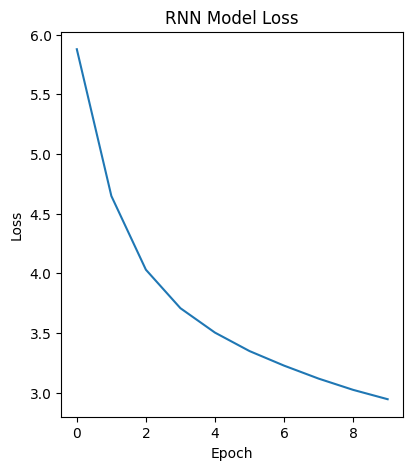

In [ ]:
import matplotlib.pyplot as plt

# Plotting RNN model loss
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
if 'rnn_history' in locals() and rnn_history is not None:
    plt.plot(rnn_history.history['loss'])
    plt.title('RNN Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
else:
    plt.text(0.5, 0.5, 'RNN history not available', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)
    plt.title('RNN Model Loss (Not Trained)')




#### LSTM

In [12]:
import gc

# --- Delete RNN objects to save memory ---
if 'rnn_model' in locals():
    del rnn_model
if 'rnn_history' in locals():
    del rnn_history
if 'rnn_generator' in locals():
    # The generator is an iterator, so simply deleting the reference might be enough,
    # but for completeness, we acknowledge it was part of the RNN training context.
    pass # No explicit del needed for generators if they've exhausted or are recreated.

gc.collect()
print("RNN-related objects cleared from memory.")


RNN-related objects cleared from memory.


In [12]:


# --- Train LSTM model ---
ids = list(id_to_captions.keys())
train_length = int(len(ids) * 0.90)
train_data = ids[:train_length]

epochs = 5 # As per the updated plan
batch_size = 128 # As per the updated plan
steps = len(train_data) // batch_size

print("\n--- Training LSTM model ---")
lstm_model = build_captioning_model('LSTM') # Re-initialize to ensure a clean model
lstm_generator = data_generator(train_data, id_to_captions, id_to_features, tokenizer, max_length, captions_size, batch_size)
lstm_history = lstm_model.fit(lstm_generator, epochs=epochs, steps_per_epoch=steps, verbose=1)
lstm_model.save('/content/lstm_model.h5')
print("LSTM model training complete and saved.")


--- Training LSTM model ---
Epoch 1/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 322s 6s/step - loss: 6.6166
Epoch 2/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 307s 5s/step - loss: 5.1413
Epoch 3/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 374s 7s/step - loss: 4.3070
Epoch 4/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 347s 6s/step - loss: 3.8584
Epoch 5/5
56/56 ━━━━━━━━━━━━━━━━━━━━ 230s 4s/step - loss: 3.6236


LSTM model training complete and saved.


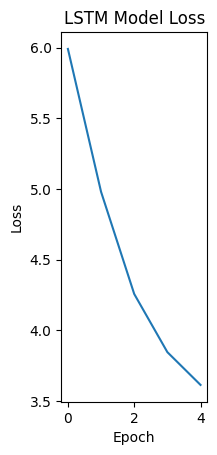

In [15]:
# Plotting LSTM model loss
import matplotlib.pyplot as plt
plt.subplot(1, 3, 2)
if 'lstm_history' in locals() and lstm_history is not None:
    plt.plot(lstm_history.history['loss'])
    plt.title('LSTM Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
else:
    plt.text(0.5, 0.5, 'LSTM history not available', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)
    plt.title('LSTM Model Loss (Not Trained)')


#### GRU

In [14]:
import gc

# --- Delete LSTM objects to save memory ---
if 'lstm_model' in locals():
    del lstm_model
if 'lstm_history' in locals():
    del lstm_history
if 'lstm_generator' in locals():
    pass # No explicit del needed for generators if they've exhausted or are recreated.

gc.collect()
print("LSTM-related objects cleared from memory.")


LSTM-related objects cleared from memory.


In [13]:


# --- Train GRU model ---
ids = list(id_to_captions.keys())
train_length = int(len(ids) * 0.90)
train_data = ids[:train_length]

epochs = 3 # As per the updated plan
batch_size = 128 # As per the updated plan
steps = len(train_data) // batch_size

print("\n--- Training GRU model ---")
gru_model = build_captioning_model('GRU') # Re-initialize to ensure a clean model
gru_generator = data_generator(train_data, id_to_captions, id_to_features, tokenizer, max_length, captions_size, batch_size)
gru_history = gru_model.fit(gru_generator, epochs=epochs, steps_per_epoch=steps, verbose=1)
gru_model.save('/content/gru_model.h5')
print("GRU model training complete and saved.")


--- Training GRU model ---
Epoch 1/3
56/56 ━━━━━━━━━━━━━━━━━━━━ 314s 6s/step - loss: 6.5869
Epoch 2/3
56/56 ━━━━━━━━━━━━━━━━━━━━ 276s 5s/step - loss: 4.8801
Epoch 3/3
56/56 ━━━━━━━━━━━━━━━━━━━━ 222s 4s/step - loss: 4.0690


GRU model training complete and saved.


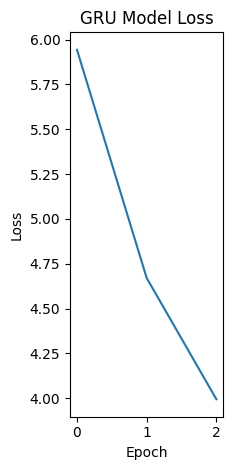

In [15]:
import matplotlib.pyplot as plt

# Plotting GRU model loss
plt.subplot(1, 3, 3)
if 'gru_history' in locals() and gru_history is not None:
    plt.plot(gru_history.history['loss'])
    plt.title('GRU Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
else:
    plt.text(0.5, 0.5, 'GRU history not available', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes)
    plt.title('GRU Model Loss (Not Trained)')

plt.tight_layout()
plt.show()

### Core Sequence Modeling Components

**Sequence length**

Sequence length affects how much information the model can use from the input. Longer sequences allow the RNN to capture more context, but they also increase training time and make learning harder due to problems like vanishing gradients.

**Hidden size**

Hidden size controls how much information the RNN can store at each time step. A larger hidden size can improve performance by learning more complex patterns, but it also increases the risk of overfitting and requires more computation.

**One vs multiple recurrent layers**

Using one recurrent layer is simpler and faster, but it may not capture complex patterns well. Multiple recurrent layers can learn higher-level features, but they are harder to train and need more data.

**Bidirectional RNNs**

Bidirectional RNNs process the sequence in both forward and backward directions. This helps the model use past and future context, which often improves performance, especially in language tasks.

**Dropout between recurrent layers**

Dropout between recurrent layers helps prevent overfitting by randomly removing connections during training. It improves generalization but too much dropout can reduce model performance.


### Discussion

LSTMs and GRUs are generally better than vanilla RNNs when working with long sequences because they are designed to remember information for a longer time. Vanilla RNNs often suffer from the vanishing gradient problem, which makes it hard for them to learn long-term dependencies.

The key reason for this improvement is the use of **gates**. In LSTMs, there are input, forget, and output gates, while GRUs use update and reset gates. These gates control how much information should be stored, updated, or forgotten at each time step. By carefully managing the flow of information, the model can keep important signals and discard less useful ones.

Gates also help reduce the vanishing gradient problem. They allow gradients to pass through the network more easily during training, which helps the model learn relationships between distant parts of a sequence. As a result, LSTMs and GRUs can capture long-term dependencies more effectively than simple RNNs.


## Part 4: Transformer Models — Attention-Based Architectures

### Load a Text Classification Dataset (IMDb)

We will first load a dataset appropriate for text classification:

In [15]:
from datasets import load_dataset

# Load IMDb dataset (binary sentiment classification)
dataset = load_dataset("imdb")

print(dataset)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


### Viewing a Sample

In [16]:
# View a sample
sample = dataset["train"][0]
print("Text:", sample["text"][:500])
print("Label:", sample["label"])


Text: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attent
Label: 0


### Load Pretrained Transformer & Tokenizer (DistilBERT)

In [17]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### Tokenizing the Dataset

In [18]:
def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=256
    )

tokenized_datasets = dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"]
)

tokenized_datasets.set_format("torch")

print(tokenized_datasets)


Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 50000
    })
})


### Preparing Training & Evaluation Data

In [20]:
train_dataset = tokenized_datasets["train"]
test_dataset = tokenized_datasets["test"]

from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./distilbert-imdb",
    eval_strategy="epoch", # Changed from evaluation_strategy
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_dir="./logs",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy"
)

### Evaluation Metrics

In [21]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average="binary"
    )
    acc = accuracy_score(labels, predictions)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }


### Training the Transformer Model

In [22]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()


/tmp/ipython-input-3446133423.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: WARNING Invalid choice
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.258100,0.254820,0.897040,0.946072,0.842080,0.891052
2,0.169600,0.260315,0.914720,0.910191,0.920240,0.915188


TrainOutput(global_step=3126, training_loss=0.23197784838734417, metrics={'train_runtime': 1473.6297, 'train_samples_per_second': 33.93, 'train_steps_per_second': 2.121, 'total_flos': 3311684966400000.0, 'train_loss': 0.23197784838734417, 'epoch': 2.0})

### Evaluating the Model

In [23]:
results = trainer.evaluate()
print(results)



{'eval_loss': 0.26031506061553955, 'eval_accuracy': 0.91472, 'eval_precision': 0.9101914859946194, 'eval_recall': 0.92024, 'eval_f1': 0.9151881613493515, 'eval_runtime': 166.954, 'eval_samples_per_second': 149.742, 'eval_steps_per_second': 9.362, 'epoch': 2.0}


In [25]:
def predict_sentiment(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    # Move input tensors to the same device as the model
    inputs = {key: value.to(model.device) for key, value in inputs.items()}
    outputs = model(**inputs)
    prediction = outputs.logits.argmax(dim=-1).item()
    return "Positive" if prediction == 1 else "Negative"

# Example
print(predict_sentiment("This movie was absolutely fantastic!"))
print(predict_sentiment("The plot was boring and predictable."))

Positive
Negative


### Discussion

**Main advantages and disadvantages of Transformer-based models**

Transformers can achieve very high accuracy and understand complex language patterns. However, they are expensive to train and require a lot of data and computing power.

**Why do they scale well with data and model size?**

Transformers can be trained in parallel and benefit directly from more data and larger models, which usually leads to better performance.

**Why do they often require large computational resources compared to simpler models?**

They use complex attention mechanisms that compare many words with each other, which increases memory usage and computation.

**What is self-attention, and what problem does it solve?**

Self-attention allows a model to focus on important words in a sentence when processing each word. It helps capture relationships between words regardless of their distance.

**Why can attention model long-range dependencies more effectively than simple RNNs?**

Attention can directly connect distant words, while RNNs process words step by step and may forget earlier information.

**What is multi-head attention, and why does it help?**

Multi-head attention uses several attention layers at the same time, allowing the model to learn different types of relationships between words.

**What is the role of positional encoding?**

Positional encoding adds information about word order, so the model knows the position of each word in a sentence.

## Part 5: Research about models (Bonus)

### 1. Investigating the Most Commonly Used Models in Industry

Based on reports such as the **Kaggle State of Data Science & Machine Learning**, industry surveys, and company engineering blogs, the most widely used machine learning models in real industrial settings today are still **classical machine learning models**, especially **Linear Regression, Logistic Regression, Decision Trees, Random Forests, and Gradient Boosting models (such as XGBoost and LightGBM)**.

These models are popular because they are **easy to train, fast to deploy, and simple to explain** to non-technical stakeholders. Many companies use them in areas like finance, marketing, healthcare, and operations, where interpretability and reliability are very important. Deep learning models are also widely used, but mainly in specific domains such as computer vision, speech recognition, and natural language processing. Overall, classical models remain the most common choice in everyday business applications.

### 2. Prediction for the Future (Next 5–10 Years)

In the next 5–10 years, the distribution of widely used machine learning models is likely to **shift gradually toward deep learning and large language model (LLM)-based approaches**, but classical models will not disappear. Simple models like linear regression and decision trees will remain dominant in many business tasks because they are cheaper, faster, and easier to maintain. Companies often prefer models that are easy to explain and meet regulatory requirements.

At the same time, **deep learning models and LLMs will gain a larger share**, especially in domains that handle large amounts of unstructured data. These include **natural language processing, customer support automation, content generation, recommendation systems, and computer vision**. As tools become easier to use and computing costs decrease, more organizations will adopt these advanced models.

The strongest shift will likely happen in **technology-driven industries**, such as software, media, e-commerce, and AI-based services. Traditional industries like banking and healthcare will adopt deep learning more slowly, mainly due to regulation and risk concerns. Overall, the future will involve a **hybrid approach**, where classical models and deep learning models are used together depending on the problem.
